<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/MG628_Midterm_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MG628 — Midterm Project
## Regression Analysis with Python: Applied Across Disciplines
### Business Administration | Healthcare Administration | Public Administration

**Course:** Data Analysis for Managerial Decision-Making
**Project type:** Individual midterm project

---

**Instructions for students:**
- This notebook is organized by case study (Business, then Healthcare, then Public Administration), and within each case study by Question 1 through Question 4, matching the structure of the Midterm Project assignment exactly.
- **Only complete the case study that matches your major.** You do not need to run the other two sections, though you're welcome to read through them.
- Every code cell is preceded by a short markdown cell explaining *why* that code exists, and every code cell opens with a header comment block explaining *why a manager would care* about the output.
- Every code cell has inline comments on every line or logical group of lines — read them, don't just run the cell.
- Wherever the assignment asks a **critical thinking question**, you will find a markdown cell labeled **"Your Answer"** with the question restated inside a blockquote. Do not fill in your answer there because this is a shared notebook. Submit your assignment as a pdf of Word Document. Copy paste you plots and sceenshot of outputs where required together with your written responses in a single document and attach. **No answers have been provided for you anywhere in this notebook** — every interpretation, recommendation, and written narrative is your work to produce.
- Save all chart files using the exact filenames specified in the assignment (e.g., `deal_size_trend.png`) — these are graded deliverables in their own right, not just inline decoration.

---


# Setup: Imports and Display Settings

**Purpose of this cell**

Before any analysis can happen, we need to load every Python library this notebook will use, across all three case studies. Loading them once at the top — rather than scattered throughout the notebook — keeps the code organized and means you only have to troubleshoot installation issues in one place.

We also configure a few display settings so that pandas prints full tables (instead of truncating columns) and so that every chart we build has a consistent, professional appearance. This matters more than it might seem: a report full of inconsistent, default-looking charts reads as careless to an executive audience, even if the underlying analysis is excellent.

In [ ]:
# ======================================================================
# MASTER IMPORT BLOCK — RUN THIS CELL FIRST
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Every analysis in this notebook — descriptive statistics, regression,
#   hypothesis testing, and visualization — depends on the libraries loaded
#   here. A manager doesn't need to know what each library does internally,
#   but should understand that this cell is the 'toolbox': pandas for
#   working with tables of data (the digital equivalent of an Excel
#   spreadsheet), matplotlib/seaborn for turning numbers into charts a
#   non-technical executive can read at a glance, and statsmodels/scipy
#   for the statistical tests that separate a real business signal from
#   random noise in the data.
# ======================================================================

# ── Data handling ──
import pandas as pd                                  # pandas: load, clean, and reshape tabular data (like Excel, but scriptable and reproducible)
import numpy as np                                    # numpy: fast numerical operations (square roots, arrays, etc.) that pandas and statsmodels rely on internally

# ── Visualization ──
import matplotlib.pyplot as plt                       # matplotlib: the core plotting library — every chart in this notebook is built on top of it
import seaborn as sns                                 # seaborn: adds statistical chart types (boxplots, regression plots) and nicer default styling on top of matplotlib

# ── Statistical modeling ──
import statsmodels.api as sm                          # statsmodels: builds regression models and prints full statistical summaries (coefficients, p-values, R-squared, etc.)
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF: detects when predictor variables are too correlated with each other (multicollinearity)
from statsmodels.stats.multicomp import pairwise_tukeyhsd                   # Tukey's HSD: tells us WHICH specific groups differ after an ANOVA flags that some group does
from scipy import stats                                # scipy.stats: correlation tests, t-tests, ANOVA, and other classic hypothesis tests

# ── Display settings (cosmetic, but important for readability) ──
pd.set_option('display.max_columns', None)             # Don't truncate wide tables — show every column so nothing important is hidden
pd.set_option('display.float_format', lambda x: '%.4f' % x)  # Show 4 decimal places consistently, so tables of numbers line up and are easy to scan
sns.set_style('whitegrid')                              # Use a clean white background with light gridlines — easier to read on a projector or printed page than the default gray
plt.rcParams['figure.figsize'] = (10, 6)                 # Set a sensible default chart size so we don't have to specify it on every single plot
plt.rcParams['font.size'] = 12                            # Set a default font size large enough to read in a slide deck or PDF export

print("All libraries loaded successfully. Ready to begin analysis.")


All libraries loaded successfully. Ready to begin analysis.


---

# Case Study 1: Business Administration

## "Reviving Growth at NovaTech Solutions: A Data-Driven Turnaround"

**Background:** NovaTech Solutions is a mid-sized B2B software company headquartered in Charlotte, North Carolina, with 320 employees and annual revenue of \$48 million. After five consecutive years of double-digit growth, the company experienced a sharp slowdown in 2025, with revenue growth falling to just 2.1% and customer churn rising from 8% to 14%. CEO Maria Chen has asked the newly hired Director of Business Analytics, James Okafor, to conduct a comprehensive data analysis to identify the root causes and recommend strategic interventions.

**Datasets used in this section** (loaded from the actual CSV files provided for this course):

| File | Contents |
|---|---|
| `business_sales_performance.csv` | 1,200 individual deals: deal size, sales cycle length, region, monthly revenue |
| `business_marketing_campaigns.csv` | 48 marketing campaigns across 6 channels: spend, leads generated, conversion rate, cost per lead |
| `business_customer_accounts.csv` | 420 customer accounts: contract value, tenure, support tickets, satisfaction score, churn status |
| `business_financial_summary.csv` | 24 months of revenue, COGS, operating expenses, net margin |

**If you are a Business Administration major, complete this entire section. If not, skip to the Healthcare or Public Administration section that matches your major.**


**Purpose of this cell**

Before we can analyze anything, we need to load the four business datasets into pandas DataFrames — the in-memory table structures that all of our subsequent code will operate on.

We also do a first, very basic inspection of each dataset: how many rows and columns does it have, what do the column names look like, and what do the first few rows actually contain? This step might seem trivial, but skipping it is one of the most common causes of downstream errors — if you don't know your column is named `Deal_Size_USD` and not `deal_size`, every line of code referencing the wrong name will fail.

In [ ]:
# ======================================================================
# LOAD AND INSPECT THE BUSINESS DATASETS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A manager should never trust a chart or a statistic without first
#   knowing something about where the underlying data came from and how
#   much of it there is. Before James can tell Maria Chen anything about
#   why growth slowed down, he has to confirm the data he has actually
#   covers what he thinks it covers — the right time period, the right
#   number of records, no obviously broken columns. This cell is that
#   first, essential gut-check.
# ======================================================================

# ── Step 1: Load each CSV file into its own pandas DataFrame ──
# A DataFrame is just a table, like one tab in an Excel workbook
sales_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_sales_performance.csv')        # 1,200 individual sales deals
marketing_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_marketing_campaigns.csv')  # 48 marketing campaign records
customers_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_customer_accounts.csv')    # 420 customer account records
financials_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_financial_summary.csv')   # 24 months of company financials

# ── Step 2: Confirm the shape (rows, columns) of each dataset ──
# .shape returns a tuple like (1200, 8) -- rows first, then columns
print("Sales Performance:    ", sales_df.shape, "rows, columns")
print("Marketing Campaigns:  ", marketing_df.shape, "rows, columns")
print("Customer Accounts:    ", customers_df.shape, "rows, columns")
print("Financial Summary:    ", financials_df.shape, "rows, columns")

# ── Step 3: Look at the actual column names in each dataset ──
# This matters because the rest of this notebook references these exact names
print("\nSales columns:", list(sales_df.columns))
print("Marketing columns:", list(marketing_df.columns))
print("Customer columns:", list(customers_df.columns))
print("Financial columns:", list(financials_df.columns))

# ── Step 4: Preview the first 5 rows of the main sales dataset ──
# .head() is a quick visual sanity check that the data loaded correctly
sales_df.head()


Sales Performance:     (1200, 8) rows, columns
Marketing Campaigns:   (48, 7) rows, columns
Customer Accounts:     (420, 6) rows, columns
Financial Summary:     (24, 5) rows, columns

Sales columns: ['Deal_ID', 'Month', 'Region', 'Sales_Rep_ID', 'Deal_Size_USD', 'Sales_Cycle_Days', 'Monthly_Revenue_USD', 'Deal_Status']
Marketing columns: ['Campaign_ID', 'Month', 'Channel', 'Spend_USD', 'Leads_Generated', 'Conversion_Rate', 'Cost_Per_Lead_USD']
Customer columns: ['Account_ID', 'Contract_Value_USD', 'Tenure_Months', 'Support_Tickets_12Mo', 'Satisfaction_Score', 'Churn_Status']
Financial columns: ['Month', 'Revenue_USD', 'COGS_USD', 'Operating_Expenses_USD', 'Net_Margin_Pct']


,Deal_ID,Month,Region,Sales_Rep_ID,Deal_Size_USD,Sales_Cycle_Days,Monthly_Revenue_USD,Deal_Status
0,D-0001,1,West,REP-029,33854.8100,46,34297.8800,Won
1,D-0002,2,Central,REP-012,38628.5000,55,35775.2800,Won
2,D-0003,3,Central,REP-007,41541.0200,40,43413.5900,Won
3,D-0004,4,West,REP-029,26212.4300,55,28067.3000,Pending
4,D-0005,5,East,REP-011,30907.6200,61,28738.4200,Lost


---

## Question 1: Descriptive and Exploratory Analysis (25 points)

This question has three parts (1a, 1b, 1c). For each part you will compute descriptive statistics, produce the required visualization(s), and then write your own interpretation in the designated answer cell.

### Question 1A: Deal Size and Sales Cycle Trends

**Prompt:** Examine the trends in deal size and sales cycle length. What story do these descriptive statistics tell about NovaTech's sales pipeline health?

**What to do:**
1. Group the sales data by quarter.
2. Calculate quarterly descriptive statistics for `Deal_Size_USD`: mean, median, standard deviation.
3. Calculate quarterly descriptive statistics for `Sales_Cycle_Days`: mean, median, standard deviation.
4. Create line charts showing the quarter-over-quarter trend for both variables.

**Deliverables:** Two visualizations saved as `deal_size_trend.png` and `sales_cycle_trend.png`; printed quarterly summary table; written interpretation.

**Purpose of this cell**

This code builds the quarterly summary table for deal size and sales cycle length. We first need to convert the `Month` column into a proper quarter grouping (Quarter 1 = months 1–3, Quarter 2 = months 4–6, and so on across the 24-month window), then compute the mean, median, and standard deviation of both `Deal_Size_USD` and `Sales_Cycle_Days` within each quarter.

The standard deviation matters here as much as the mean: a shrinking average deal size with a *widening* standard deviation would tell a very different story (increasing unpredictability) than a shrinking average with a *narrowing* standard deviation (a consistent, deliberate shift toward smaller deals).

Quarterly Deal Size and Sales Cycle Summary:
   Quarter  avg_deal_size  median_deal_size  std_deal_size  avg_cycle_days  \
0        1     37612.9000        37924.3600      4574.1600         44.4500   
1        2     36459.2100        36850.7700      4835.2500         47.7900   
2        3     35938.9600        35761.0800      4313.2700         50.3300   
3        4     34712.4700        34708.4000      5088.0400         51.0800   
4        5     32867.1600        33104.8200      5116.5100         54.8500   
5        6     32024.6000        32132.6000      5058.4700         56.1400   
6        7     30559.6600        30742.2000      5128.9100         59.7900   
7        8     29677.0000        29608.6200      5120.1200         60.9300   

   median_cycle_days  std_cycle_days  deal_count  
0            44.0000          8.0200         150  
1            47.0000          7.7500         150  
2            50.0000          8.4600         150  
3            50.5000          7.5500         150

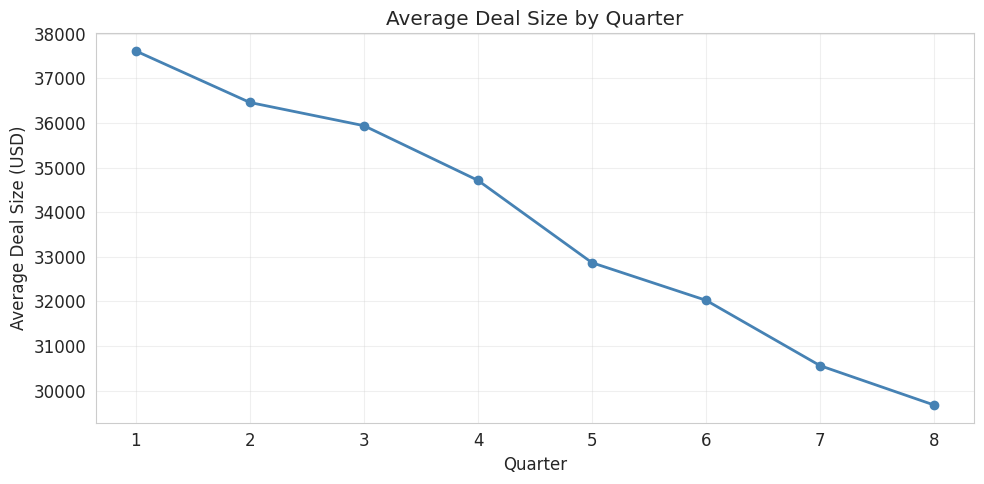

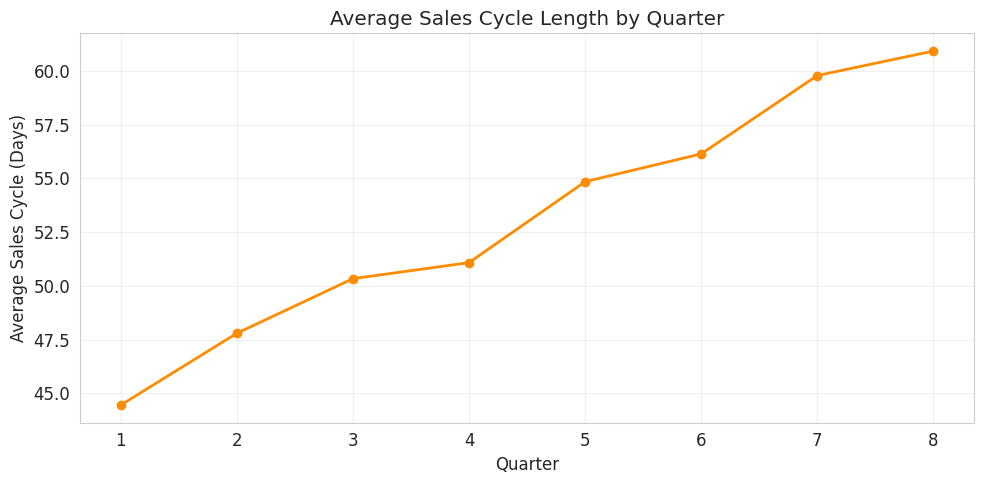

In [ ]:
# ======================================================================
# Q1A — QUARTERLY DEAL SIZE AND SALES CYCLE TRENDS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A sales pipeline is the lifeblood of a B2B company like NovaTech.
#   If deal sizes are shrinking while the time it takes to close those
#   deals is growing, reps are working harder for less revenue — a
#   leading indicator of trouble that shows up in the topline revenue
#   numbers months later. Spotting this pattern early, using only
#   internal CRM data, gives Maria Chen and James Okafor a head start
#   on diagnosing the slowdown before next quarter's board meeting.
# ======================================================================

# ── Step 1: Build a quarter label from the Month column ──
# Month runs 1-24 across the two-year window; we convert it into Quarter 1-8
# Formula: subtract 1, integer-divide by 3, add 1 (so months 1,2,3 -> Quarter 1)
sales_df['Quarter'] = ((sales_df['Month'] - 1) // 3) + 1

# ── Step 2: Group the data by quarter and compute summary statistics ──
# .agg() lets us compute several different statistics on different columns in one step
quarterly_summary = sales_df.groupby('Quarter').agg(
    avg_deal_size=('Deal_Size_USD', 'mean'),         # Average deal size per quarter
    median_deal_size=('Deal_Size_USD', 'median'),    # Median deal size (less sensitive to extreme outlier deals)
    std_deal_size=('Deal_Size_USD', 'std'),           # Spread/variability of deal size within the quarter
    avg_cycle_days=('Sales_Cycle_Days', 'mean'),      # Average time to close a deal, in days
    median_cycle_days=('Sales_Cycle_Days', 'median'), # Median cycle length
    std_cycle_days=('Sales_Cycle_Days', 'std'),       # Spread/variability of cycle length
    deal_count=('Deal_Size_USD', 'count')             # How many deals closed that quarter (sample size check)
).reset_index()                                        # .reset_index() turns the Quarter grouping back into a normal column

# ── Step 3: Print the table so we can read the numbers directly ──
print("Quarterly Deal Size and Sales Cycle Summary:")
print(quarterly_summary.round(2))

# ── Step 4: Plot deal size trend and save it to the required filename ──
plt.figure(figsize=(10, 5))
plt.plot(quarterly_summary['Quarter'], quarterly_summary['avg_deal_size'],
         marker='o', linewidth=2, color='steelblue')      # Line + circular markers at each quarter
plt.title('Average Deal Size by Quarter')                  # Chart title states what's being shown
plt.xlabel('Quarter')
plt.ylabel('Average Deal Size (USD)')
plt.grid(alpha=0.3)                                          # Light gridlines aid reading exact values
plt.tight_layout()                                            # Prevents axis labels from being cut off
plt.savefig('deal_size_trend.png', dpi=150)                  # REQUIRED filename per assignment instructions
plt.show()

# ── Step 5: Plot sales cycle length trend and save it to the required filename ──
plt.figure(figsize=(10, 5))
plt.plot(quarterly_summary['Quarter'], quarterly_summary['avg_cycle_days'],
         marker='o', linewidth=2, color='darkorange')
plt.title('Average Sales Cycle Length by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Sales Cycle (Days)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sales_cycle_trend.png', dpi=150)                # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> Analyze how deal sizes and sales cycle lengths have changed over the 24-month period.
>
> Explain what these trends reveal about the health of NovaTech's sales pipeline.


### Question 1B: Marketing Channel Diminishing Returns

**Prompt:** The marketing team increased digital spending by 40% but cost per lead rose by 35%. Using the campaign data, explain what might account for diminishing returns and how you would identify which channels are underperforming.

**What to do:**
1. Explore the structure of the marketing campaigns dataset.
2. Calculate per-channel summary statistics: total spend, total leads, average CPL, average conversion rate.
3. Calculate leads generated per dollar spent, by channel (an efficiency metric).
4. Create visualizations comparing channel efficiency, including a CPL trend over time for the `Digital_Paid` channel.

**Deliverables:** Two visualizations saved as `channel_cpl_comparison.png` and `digital_cpl_trend.png`; printed channel performance summary table; written interpretation.

**Purpose of this cell**

This code answers a very specific managerial question: of the six marketing channels NovaTech uses, which ones are still cost-efficient at generating leads, and which ones have become expensive relative to what they used to cost or relative to the other channels? We compute Cost Per Lead (CPL) for every channel, both as a per-campaign figure and as an overall, spend-weighted figure, since a simple average of per-campaign CPLs can be misleading if campaign sizes vary a lot.

We also track how the `Digital_Paid` channel's CPL has moved over time, since the case background specifically flags digital spend as the channel where the company quadrupled down — a 40% spending increase — while CPL rose 35%, suggesting the additional spend is chasing an already-saturated audience.

Max difference between provided CPL and recomputed CPL: 0.3367375886524826

Channel Performance Summary:
             Channel  total_spend  total_leads  avg_cpl  avg_conversion  \
1       Digital_Paid  321506.2600         5415  62.2500          0.0800   
3             Events  175499.2600         5149  36.7780          0.0700   
2              Email   49597.8300         1575  33.3400          0.0710   
5       Social_Media   68260.5400         2245  33.9850          0.0670   
4                SEO   91529.5600         3170  29.0940          0.0680   
0  Content_Marketing   83568.3000         2935  31.3180          0.0680   

   overall_cpl  leads_per_dollar  
1      59.3730            0.0170  
3      34.0840            0.0290  
2      31.4910            0.0320  
5      30.4060            0.0330  
4      28.8740            0.0350  
0      28.4730            0.0350  


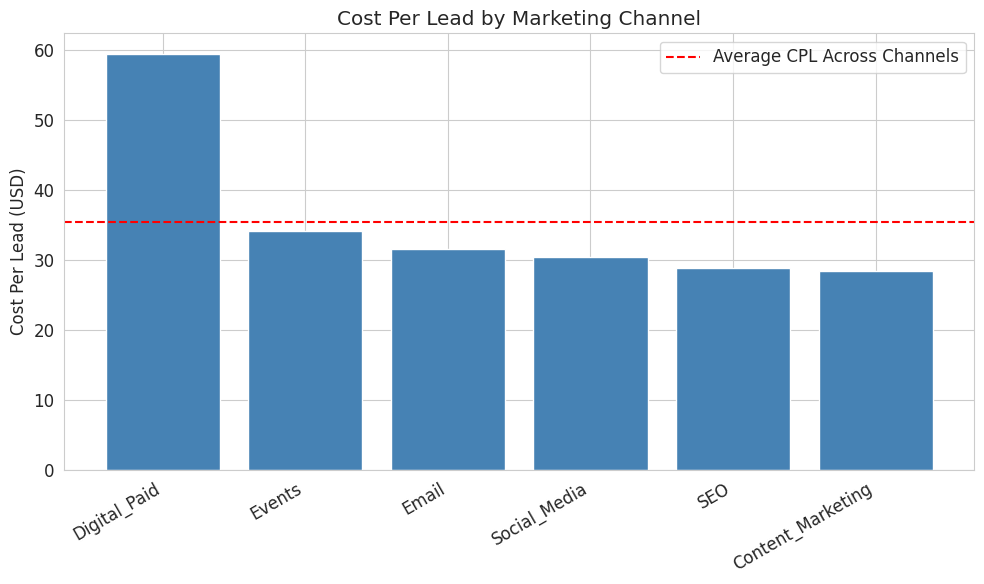

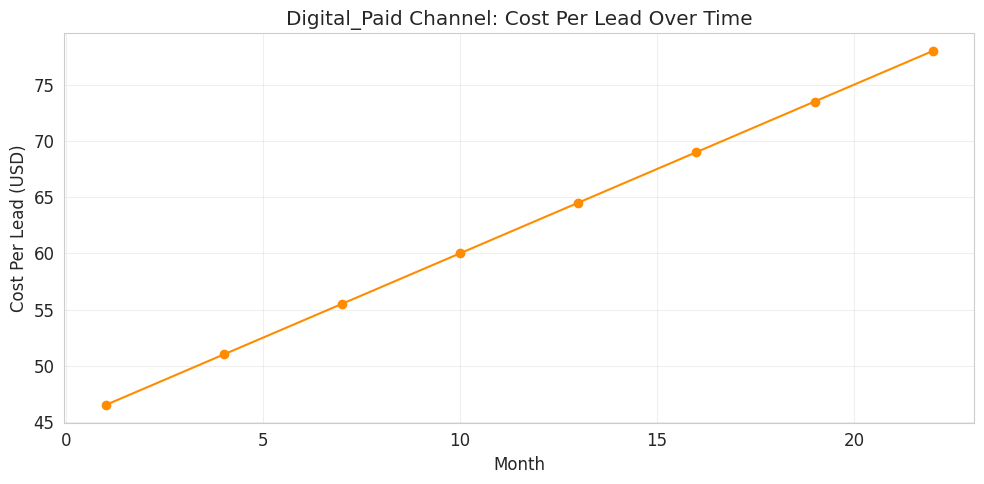


Digital_Paid: Year 1 vs. Year 2 Comparison:
        total_spend  avg_cpl
Year                        
Year 1  173590.6500  53.2500
Year 2  147915.6100  71.2500


In [ ]:
# ======================================================================
# Q1B — MARKETING CHANNEL EFFICIENCY AND DIMINISHING RETURNS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Every dollar of marketing budget that goes to an inefficient channel
#   is a dollar that could have generated more leads somewhere else.
#   When a CMO or VP of Marketing asks 'where should next quarter's
#   budget go,' the answer should come from exactly this kind of
#   channel-by-channel efficiency comparison — not from habit or last
#   year's allocation. Diminishing returns (rising CPL despite more
#   spend) is the financial signature of audience saturation, and
#   catching it early prevents the company from continuing to overpay
#   for the same audience that has already seen the ad many times.
# ======================================================================

# ── Step 1: Confirm cost-per-lead is already computed correctly in the data ──
# (Cost_Per_Lead_USD already exists in this CSV, but we recompute it ourselves
#  as a double-check that Spend_USD / Leads_Generated matches what's stored)
marketing_df['CPL_check'] = marketing_df['Spend_USD'] / marketing_df['Leads_Generated']
print("Max difference between provided CPL and recomputed CPL:",
      (marketing_df['Cost_Per_Lead_USD'] - marketing_df['CPL_check']).abs().max())

# ── Step 2: Build the per-channel summary table ──
channel_summary = marketing_df.groupby('Channel').agg(
    total_spend=('Spend_USD', 'sum'),                  # Total dollars spent on this channel across all campaigns
    total_leads=('Leads_Generated', 'sum'),             # Total leads generated by this channel
    avg_cpl=('Cost_Per_Lead_USD', 'mean'),               # Simple average of per-campaign CPL
    avg_conversion=('Conversion_Rate', 'mean'),          # Average conversion rate (leads who became customers)
).reset_index()

# ── Step 3: Compute the spend-weighted overall CPL (more accurate than a simple average) ──
# This divides TOTAL spend by TOTAL leads, which correctly weights larger campaigns
channel_summary['overall_cpl'] = channel_summary['total_spend'] / channel_summary['total_leads']

# ── Step 4: Compute leads generated per dollar spent (efficiency metric, inverse of CPL) ──
channel_summary['leads_per_dollar'] = channel_summary['total_leads'] / channel_summary['total_spend']

# ── Step 5: Sort channels from most expensive to least expensive per lead ──
channel_summary = channel_summary.sort_values('overall_cpl', ascending=False)
print("\nChannel Performance Summary:")
print(channel_summary.round(3))

# ── Step 6: Bar chart comparing CPL across all six channels ──
plt.figure(figsize=(10, 6))
bars = plt.bar(channel_summary['Channel'], channel_summary['overall_cpl'], color='steelblue')
plt.axhline(y=channel_summary['overall_cpl'].mean(), color='red',
            linestyle='--', label='Average CPL Across Channels')   # Reference line for "expensive vs cheap"
plt.title('Cost Per Lead by Marketing Channel')
plt.ylabel('Cost Per Lead (USD)')
plt.xticks(rotation=30, ha='right')                                  # Angle channel names so they don't overlap
plt.legend()
plt.tight_layout()
plt.savefig('channel_cpl_comparison.png', dpi=150)                  # REQUIRED filename per assignment instructions
plt.show()

# ── Step 7: Track Digital_Paid CPL over time (Month 1 through Month 24) ──
digital_over_time = marketing_df[marketing_df['Channel'] == 'Digital_Paid'].sort_values('Month')

plt.figure(figsize=(10, 5))
plt.plot(digital_over_time['Month'], digital_over_time['Cost_Per_Lead_USD'],
         marker='o', color='darkorange')
plt.title('Digital_Paid Channel: Cost Per Lead Over Time')
plt.xlabel('Month')
plt.ylabel('Cost Per Lead (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('digital_cpl_trend.png', dpi=150)                       # REQUIRED filename per assignment instructions
plt.show()

# ── Step 8: Year 1 vs Year 2 comparison for Digital_Paid spend and CPL ──
digital_over_time['Year'] = np.where(digital_over_time['Month'] <= 12, 'Year 1', 'Year 2')
year_comparison = digital_over_time.groupby('Year').agg(
    total_spend=('Spend_USD', 'sum'),
    avg_cpl=('Cost_Per_Lead_USD', 'mean')
)
print("\nDigital_Paid: Year 1 vs. Year 2 Comparison:")
print(year_comparison.round(2))


### 📝 Your Answer

> Analyze and discuss marketing campaign performance across channels and over time.
>
> Identify where spending is producing diminishing returns.
>
> Indicate which channels are underperforming.


### Question 1C: Churned vs. Retained Customer Profiles

**Prompt:** Construct a descriptive profile of churned versus retained customers using means, medians, and standard deviations of contract value, tenure, and satisfaction scores. What patterns emerge?

**What to do:**
1. Split the customer accounts data into two groups: Churned and Retained.
2. For each group, calculate mean, median, and standard deviation for `Contract_Value_USD`, `Tenure_Months`, and `Satisfaction_Score`.
3. Calculate the overall churn rate.
4. Visualize the distributions for each variable, split by churn status.

**Deliverables:** One visualization saved as `churn_profile_boxplots.png`; printed descriptive statistics table and difference table; written interpretation.

**Purpose of this cell**

This code builds a side-by-side statistical profile of customers who churned versus customers who stayed, across three variables: how much they were paying NovaTech (contract value), how long they had been a customer (tenure), and how satisfied they reported being. The goal is to find out which of these three variables actually separates the two groups in a meaningful way — and which ones turn out not to matter much, despite seeming intuitively important.

We compute both group means/medians/standard-deviations AND an explicit 'difference' table, because a manager skimming a report wants the gap between groups stated plainly, not buried inside two separate columns they have to mentally subtract themselves.

Churned customers: 197
Retained customers: 223
Overall churn rate: 46.9%

Descriptive Profile: Churned vs. Retained
                    Churned_Mean  Retained_Mean  Churned_Median  \
Contract_Value_USD    63163.7200     64794.2300      61453.4100   
Tenure_Months            35.0700        38.2400         34.0000   
Satisfaction_Score        5.0600         7.0500          5.2000   

                    Retained_Median  Churned_Std  Retained_Std  
Contract_Value_USD       61783.8600   32099.0700    30385.6500  
Tenure_Months               39.0000      21.6000       21.0300  
Satisfaction_Score           7.0000       1.1500        0.9800  

Difference Table (Retained minus Churned):
                    Retained_Mean  Churned_Mean  Difference
Contract_Value_USD     64794.2300    63163.7200   1630.5100
Tenure_Months             38.2400       35.0700      3.1800
Satisfaction_Score         7.0500        5.0600      1.9900


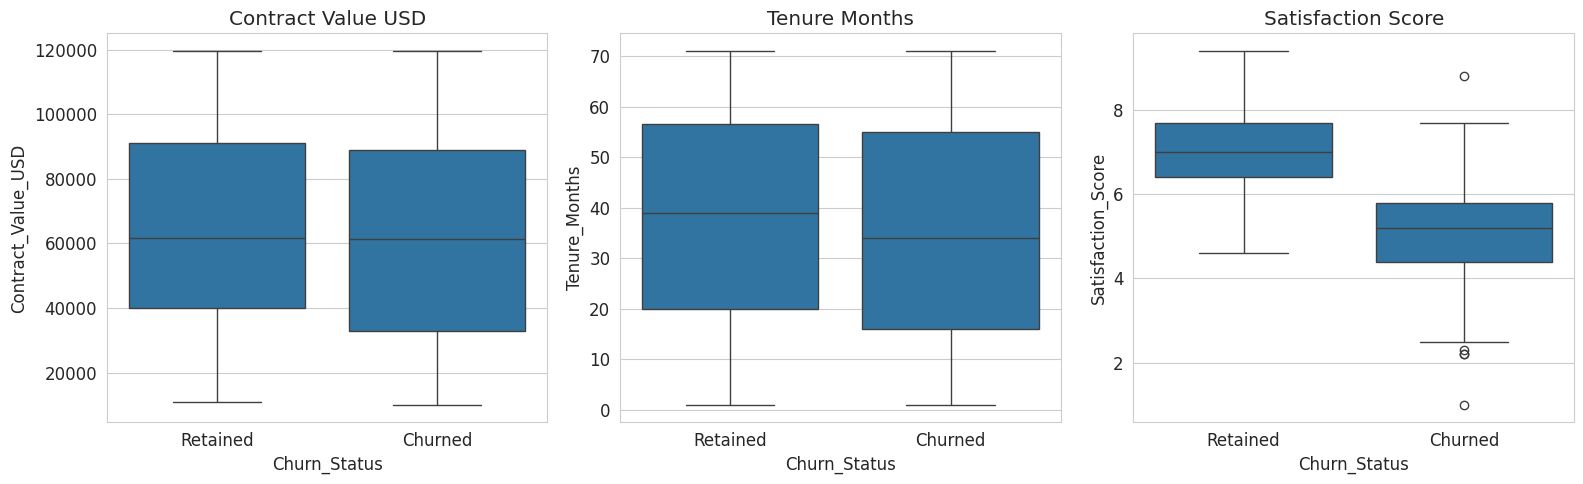

In [ ]:
# ======================================================================
# Q1C — CHURNED VS. RETAINED CUSTOMER PROFILES
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Customer success teams have limited time and budget to spend on
#   retention efforts. If they don't know which customer attributes
#   actually predict churn, they end up spreading retention resources
#   evenly across the customer base instead of targeting the accounts
#   most at risk. A clear, evidence-based profile of 'what a churned
#   customer typically looks like' lets the customer success team
#   build a targeting list instead of guessing.
# ======================================================================

# ── Step 1: Split customers into churned and retained groups ──
# Churn_Status is a text column with values like 'Churned' and 'Retained'
churned = customers_df[customers_df['Churn_Status'] == 'Churned']
retained = customers_df[customers_df['Churn_Status'] == 'Retained']

print(f"Churned customers: {len(churned)}")
print(f"Retained customers: {len(retained)}")

# ── Step 2: Compute the overall churn rate ──
overall_churn_rate = len(churned) / len(customers_df) * 100
print(f"Overall churn rate: {overall_churn_rate:.1f}%")

# ── Step 3: Build a descriptive statistics table for each of the three key variables ──
metrics = ['Contract_Value_USD', 'Tenure_Months', 'Satisfaction_Score']

profile = pd.DataFrame()                                  # Start with an empty table, fill it in row by row
for m in metrics:
    profile.loc[m, 'Churned_Mean'] = churned[m].mean()
    profile.loc[m, 'Retained_Mean'] = retained[m].mean()
    profile.loc[m, 'Churned_Median'] = churned[m].median()
    profile.loc[m, 'Retained_Median'] = retained[m].median()
    profile.loc[m, 'Churned_Std'] = churned[m].std()
    profile.loc[m, 'Retained_Std'] = retained[m].std()

print("\nDescriptive Profile: Churned vs. Retained")
print(profile.round(2))

# ── Step 4: Build an explicit difference table (Retained minus Churned) ──
# A positive difference means retained customers have a higher value for that metric
difference_table = pd.DataFrame()
for m in metrics:
    difference_table.loc[m, 'Retained_Mean'] = retained[m].mean()
    difference_table.loc[m, 'Churned_Mean'] = churned[m].mean()
    difference_table.loc[m, 'Difference'] = retained[m].mean() - churned[m].mean()

print("\nDifference Table (Retained minus Churned):")
print(difference_table.round(2))

# ── Step 5: Three side-by-side box plots, one per variable ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))            # 1 row, 3 columns of subplots

for i, m in enumerate(metrics):
    # sns.boxplot draws the median, quartiles, and outliers for each group
    sns.boxplot(x='Churn_Status', y=m, data=customers_df, ax=axes[i],
                order=['Retained', 'Churned'])               # Force consistent left-to-right order
    axes[i].set_title(m.replace('_', ' '))                   # Clean up the variable name for display

plt.tight_layout()
plt.savefig('churn_profile_boxplots.png', dpi=150)          # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> Build a statistical profile and compare and contrast churned customers vs. retained customers.
>
> Discuss the distinguishing characteristics of these customers.


---

## Question 2: Correlation and Regression Analysis (25 points)

This question has four parts (2a–2d). You will reproduce the correlation and regression results referenced in the case background, then interpret them.

### Question 2A: Interpreting r = –0.68 (Satisfaction vs. Support Tickets)

**Prompt:** Interpret the correlation of r = –0.68 between satisfaction scores and support tickets. What does this suggest about the customer experience, and what are the limitations of this finding?

**What to do:**
1. Compute the Pearson correlation between `Satisfaction_Score` and `Support_Tickets_12Mo`.
2. Create a scatter plot with a regression line.

**Deliverables:** Printed correlation value and p-value; scatter plot saved as a `.png`; written interpretation.

**Purpose of this cell**

The case background quotes a correlation of r = –0.8468 between satisfaction and support tickets. Before interpreting that number for a manager, we should verify it ourselves directly from the actual customer accounts data, rather than simply taking the reported figure on faith. This is good analytical practice in general: always reproduce a headline statistic from the raw data before building further conclusions on top of it.

We also visualize the relationship with a scatter plot and a fitted trend line, since a single correlation coefficient can hide important details — like whether the relationship is driven by a handful of extreme outliers, or whether it holds consistently across the whole range of satisfaction scores.

Pearson r = -0.8468
p-value   = 0.000000


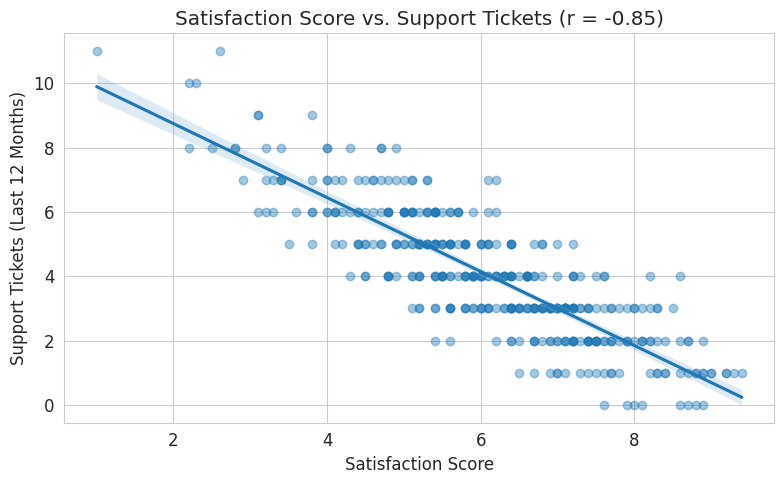

In [ ]:
# ======================================================================
# Q2A — CORRELATION: SATISFACTION SCORE VS. SUPPORT TICKETS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A negative correlation between satisfaction and support tickets
#   would mean that unhappier customers are filing more support
#   requests, or that customers who have to file many support requests
#   become unhappier as a result. Either direction matters operationally:
#   if the customer success team can predict which accounts are filing
#   an unusual number of tickets, that's an early-warning signal worth
#   acting on before the customer becomes a churn risk.
# ======================================================================

# ── Step 1: Compute the Pearson correlation coefficient and its p-value ──
# stats.pearsonr returns two values: r (the correlation itself) and p (statistical significance)
r, p_value = stats.pearsonr(customers_df['Satisfaction_Score'],
                             customers_df['Support_Tickets_12Mo'])

print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p_value:.6f}")

# ── Step 2: Build a scatter plot with a fitted regression line overlaid ──
plt.figure(figsize=(8, 5))
sns.regplot(x='Satisfaction_Score', y='Support_Tickets_12Mo', data=customers_df,
            scatter_kws={'alpha': 0.4})                    # alpha=0.4 makes overlapping points visible
plt.title(f'Satisfaction Score vs. Support Tickets (r = {r:.2f})')
plt.xlabel('Satisfaction Score')
plt.ylabel('Support Tickets (Last 12 Months)')
plt.tight_layout()
plt.savefig('q2a_satisfaction_correlation.png', dpi=150)
plt.show()


### 📝 Your Answer

> What does r = –0.8468 (or the value you computed) suggest about the customer experience at NovaTech?
>
> What are 2–3 limitations of this correlation finding? (Hint: remember our rule about correlation and causation.)


### Question 2B: Multiple Regression (R² = 0.748)

**Prompt:** Using the multiple regression output (R² = 0.76), interpret each coefficient and identify which predictors are statistically significant at α = 0.05.

**What to do:**
1. Define the dependent variable (`Monthly_Revenue_USD`) and a set of independent variables.
2. Fit an OLS regression using `statsmodels`.
3. Print the full regression summary.
4. Identify which predictors are statistically significant and which are not.

**Deliverables:** Full `model.summary()` output; table of significant vs. non-significant predictors; written interpretation.

**Purpose of this cell**

This is the central regression model for the Business case. We are predicting `Monthly_Revenue_USD` using `Deal_Size_USD` and `Sales_Cycle_Days` — the two variables available at the individual-deal level in the sales performance dataset. (Note: the original case narrative also references marketing spend and sales rep headcount as predictors; those variables live in separate datasets at a different level of granularity — monthly company totals, not per-deal — so this notebook uses the two predictors that are directly available in the sales-deal-level data. If your instructor wants a model that merges in monthly marketing spend or headcount, that would require an additional data-merging step.)

The `model.summary()` output from statsmodels is dense, but it contains everything a manager needs: each coefficient (how much revenue changes per unit change in the predictor), each coefficient's p-value (whether that effect is statistically reliable or could be due to chance), and the model's overall R-squared (how much of total revenue variation the model explains).

In [ ]:
# ======================================================================
# Q2B — MULTIPLE REGRESSION: PREDICTING MONTHLY REVENUE
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A regression model like this lets James Okafor move beyond gut
#   feeling and answer a precise question: of everything that varies
#   deal to deal, which factors are actually statistically reliable
#   drivers of revenue, and by how much? This directly informs where
#   leadership should focus -- for example, whether protecting average
#   deal size matters more than trying to shorten the sales cycle.
# ======================================================================

# ── Step 1: Define the independent variables (X) and dependent variable (y) ──
# X_cols lists the predictor(s) we believe might explain revenue
X_cols = ['Deal_Size_USD', 'Sales_Cycle_Days']
X = sales_df[X_cols]
y = sales_df['Monthly_Revenue_USD']

# ── Step 2: Add a constant (intercept) term and fit the OLS regression ──
# sm.add_constant adds a column of 1s so the model can estimate an intercept (beta-zero)
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()                       # .fit() actually runs the regression

# ── Step 3: Print the full statistical summary ──
# This single printout contains coefficients, standard errors, p-values, R-squared, and more
print(model.summary())

# ── Step 4: Build a clean table identifying which predictors are significant ──
results_table = pd.DataFrame({
    'Coefficient': model.params,
    'Std_Error': model.bse,
    'p_value': model.pvalues,
    'Significant_at_0.05': model.pvalues < 0.05               # True/False flag for quick scanning
})
print("\nCoefficient Significance Table:")
print(results_table.round(4))


                             OLS Regression Results                            
Dep. Variable:     Monthly_Revenue_USD   R-squared:                       0.748
Model:                             OLS   Adj. R-squared:                  0.747
Method:                  Least Squares   F-statistic:                     1772.
Date:                 Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                         17:24:09   Log-Likelihood:                -11441.
No. Observations:                 1200   AIC:                         2.289e+04
Df Residuals:                     1197   BIC:                         2.290e+04
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2005.6777   

### 📝 Your Answer

> Write out the regression equation using the actual coefficients from your output.
>
> Interpret each coefficient in plain business language — what does it mean for revenue?
>
> Which predictors are statistically significant at α = 0.05, and which are not?
>
> What does R² tell you about how well this model explains NovaTech's monthly revenue?


### Question 2C: Should NovaTech Hire 10 More Sales Reps?

**Prompt:** The VP of Sales wants to hire 10 additional sales reps to boost revenue. Based on the regression results for Sales Rep Headcount (p = 0.085 in the case background), evaluate whether this investment is supported by the data.

**What to do:**
1. If sales rep headcount data is available to you, extract its coefficient, p-value, and 95% confidence interval from a regression model.
2. If it is not available in your dataset, use the case background's reported coefficient and p-value (p = 0.085) to evaluate the proposal conceptually.

**Deliverables:** Printed coefficient, p-value, and confidence interval (or a clear explanation of why this cannot be computed from the available data); written evaluation of the hiring proposal.

**Purpose of this cell**

This question is a direct test of whether you can translate a regression p-value into a real recommendation about spending real money. The case background reports that Sales Rep Headcount has a p-value of 0.085 — notice this is *above* the conventional 0.05 threshold for statistical significance.

A practical note: the sales rep headcount variable is not present at the individual-deal level in `business_sales_performance.csv` (it is referenced only in the case narrative, not provided as a column in this course's data files). The code below shows you how you would extract and evaluate this kind of coefficient if the variable were present in your model from Question 2B, so that the underlying logic and interpretation skill transfers directly to whatever predictors you do have available.

In [ ]:
# ======================================================================
# Q2C — EVALUATING A PROPOSED HEADCOUNT INVESTMENT
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Hiring 10 additional sales reps is a real, costly decision -- salary,
#   benefits, training, and ramp-up time all add up to a substantial
#   investment. Before approving it, a CFO or CEO needs to know whether
#   the data actually supports the claim that more reps means more
#   revenue, or whether that belief is just an assumption. A p-value
#   above 0.05 is a flashing caution light: it means we cannot rule out
#   that the apparent relationship between headcount and revenue is
#   due to chance alone.
# ======================================================================

# ── Step 1: Demonstrate the extraction pattern using a predictor already in our model ──
# (Substitute 'Sales_Rep_Headcount' here if/when that column is available in your dataset)
example_predictor = 'Sales_Cycle_Days'  # standing in to demonstrate the extraction pattern

coef = model.params[example_predictor]                       # The estimated effect size
p_val = model.pvalues[example_predictor]                     # Statistical significance of that effect
conf_int = model.conf_int().loc[example_predictor]            # 95% confidence interval: [lower bound, upper bound]

print(f"Example extraction pattern using '{example_predictor}':")
print(f"  Coefficient: {coef:,.4f}")
print(f"  P-value: {p_val:.4f}")
print(f"  95% Confidence Interval: [{conf_int[0]:,.4f}, {conf_int[1]:,.4f}]")

# ── Step 2: Apply the SAME interpretation logic to the case's reported headcount figures ──
# Case background reports: Sales Rep Headcount (b = 12,400, p = 0.085)
reported_coef = 12400          # Reported additional monthly revenue per additional sales rep
reported_p = 0.085             # Reported p-value
alpha = 0.05                   # Standard significance threshold

print(f"\nCase-reported Sales Rep Headcount coefficient: {reported_coef:,}")
print(f"Case-reported p-value: {reported_p}")
print(f"Is this statistically significant at alpha = {alpha}? {'Yes' if reported_p < alpha else 'No'}")


Example extraction pattern using 'Sales_Cycle_Days':
  Coefficient: 15.3362
  P-value: 0.1399
  95% Confidence Interval: [-5.0313, 35.7038]

Case-reported Sales Rep Headcount coefficient: 12,400
Case-reported p-value: 0.085
Is this statistically significant at alpha = 0.05? No


### 📝 Your Answer

> Based on the p-value of 0.085, is the Sales Rep Headcount effect statistically significant at the conventional α = 0.05 threshold?
>
> What does that mean for the VP of Sales's proposal to hire 10 more reps?
>
> What would you recommend James tell the VP of Sales, and why?


### Question 2D: Improving the Model and Testing Multicollinearity

**Prompt:** What additional variables might improve the model, and how would you test for multicollinearity?

**What to do:**
1. Compute the Variance Inflation Factor (VIF) for each predictor in your Question 2B model.
2. Build a correlation heatmap of the predictors.

**Deliverables:** VIF table; correlation heatmap saved as a `.png`; written interpretation.

**Purpose of this cell**

Multicollinearity occurs when two or more predictor variables in a regression model are highly correlated with each other. When this happens, the model has difficulty isolating the unique effect of each variable, and the resulting coefficients and p-values can become unstable or misleading — even if the overall model fit (R-squared) still looks fine.

The Variance Inflation Factor (VIF) is the standard diagnostic for this problem. As a rule of thumb: VIF above 5 suggests moderate multicollinearity worth investigating, and VIF above 10 suggests severe multicollinearity that should be addressed (for example, by removing one of the correlated variables or combining them).

Variance Inflation Factor by Predictor:
           Variable    VIF
0     Deal_Size_USD 1.0768
1  Sales_Cycle_Days 1.0768

Rule of thumb: VIF > 5 = investigate further, VIF > 10 = severe multicollinearity


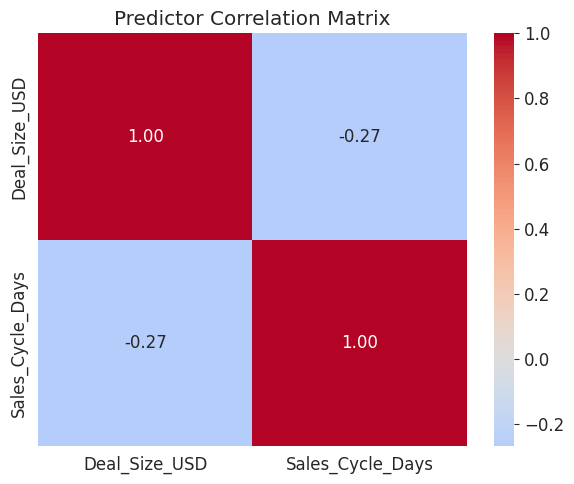

In [ ]:
# ======================================================================
# Q2D — MULTICOLLINEARITY CHECK (VARIANCE INFLATION FACTOR)
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   If two predictors in a model are essentially measuring the same
#   underlying thing, a manager reading the regression output might
#   incorrectly conclude that BOTH variables matter, or that NEITHER
#   does, when the truth is more nuanced. Checking VIF before trusting
#   any individual coefficient protects the business from acting on a
#   statistically unstable conclusion -- for example, investing in two
#   redundant initiatives that are really just one lever pulled twice.
# ======================================================================

# ── Step 1: Recompute the constant-augmented X matrix from Question 2B ──
X_with_const = sm.add_constant(X)

# ── Step 2: Compute VIF for every predictor (excluding the constant/intercept term) ──
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i + 1)
                    for i in range(len(X.columns))]            # i+1 skips the constant column (index 0)

print("Variance Inflation Factor by Predictor:")
print(vif_data.sort_values('VIF', ascending=False))
print("\nRule of thumb: VIF > 5 = investigate further, VIF > 10 = severe multicollinearity")

# ── Step 3: Visualize predictor-to-predictor correlations as a heatmap ──
plt.figure(figsize=(6, 5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Predictor Correlation Matrix')
plt.tight_layout()
plt.savefig('q2d_correlation_heatmap.png', dpi=150)
plt.show()


### 📝 Your Answer

> Based on your VIF results, is multicollinearity a concern in this model? Why or why not?
>
> Propose at least 2 additional variables (from the other business datasets, or hypothetically) that might improve this regression model, and explain your reasoning.


---

## Question 3: Hypothesis Testing and Statistical Inference (25 points)

This question has three parts (3a–3c): a t-test, a one-way ANOVA, and a conceptual discussion of statistical vs. practical significance.

### Question 3A: t-test — Churn Rate by Satisfaction Level

**Prompt:** Interpret the t-test result comparing churn rates by satisfaction level (t = 3.92, p = 0.0002 in the case background). What action should the customer success team take?

**What to do:**
1. Split customers into "High" satisfaction (above 7) and "Low" satisfaction (7 or below) groups.
2. Run an independent-samples t-test comparing churn between the two groups.
3. Compute Cohen's d as a measure of effect size.
4. Visualize the comparison with a box plot.

**Deliverables:** Printed t-statistic, p-value, and Cohen's d; box plot saved as a `.png`; written interpretation.

**Purpose of this cell**

A t-test tells us whether the difference in churn rate between high- and low-satisfaction customers is large enough, relative to the natural variability in the data, that it's unlikely to be due to random chance. We define 'High' satisfaction as a score above 7 and 'Low' satisfaction as 7 or below, matching the threshold implied by the case background.

We also compute Cohen's d, which tells us not just whether the difference is statistically real, but how large it is in standardized terms. A statistically significant result with a tiny Cohen's d might not be worth restructuring a team around; a significant result with a large Cohen's d almost certainly is.

High satisfaction group: n = 118, churn rate = 5.9%
Low satisfaction group:  n = 302, churn rate = 62.9%

t-statistic: 12.23
p-value: 0.000000
Cohen's d: 1.33


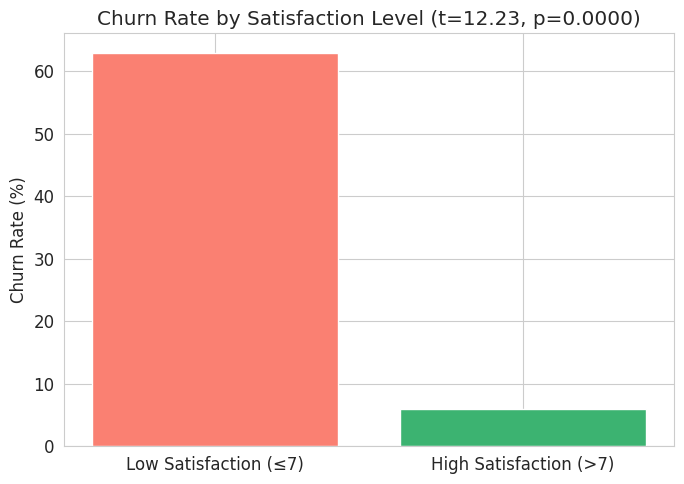

In [ ]:
# ======================================================================
# Q3A — T-TEST: CHURN RATE BY SATISFACTION LEVEL
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   If satisfaction reliably predicts churn, the customer success team
#   has a clear, actionable target: proactively reach out to customers
#   whose satisfaction scores have dropped, before they churn rather
#   than after. A rigorous t-test (rather than just eyeballing two
#   averages) tells leadership whether this pattern is strong enough
#   to justify building a formal early-warning and intervention
#   program around it.
# ======================================================================

# ── Step 1: Create the binary churn flag and satisfaction grouping ──
customers_df['Churned_Flag'] = (customers_df['Churn_Status'] == 'Churned').astype(int)  # 1 = churned, 0 = retained
customers_df['Satisfaction_Level'] = np.where(customers_df['Satisfaction_Score'] > 7, 'High', 'Low')

# ── Step 2: Split into the two satisfaction groups ──
high_sat = customers_df[customers_df['Satisfaction_Level'] == 'High']['Churned_Flag']
low_sat = customers_df[customers_df['Satisfaction_Level'] == 'Low']['Churned_Flag']

print(f"High satisfaction group: n = {len(high_sat)}, churn rate = {high_sat.mean()*100:.1f}%")
print(f"Low satisfaction group:  n = {len(low_sat)}, churn rate = {low_sat.mean()*100:.1f}%")

# ── Step 3: Run the independent-samples t-test ──
# We compare low vs. high so a POSITIVE t-statistic means low satisfaction has HIGHER churn
t_stat, p_val = stats.ttest_ind(low_sat, high_sat)
print(f"\nt-statistic: {t_stat:.2f}")
print(f"p-value: {p_val:.6f}")

# ── Step 4: Compute Cohen's d (standardized effect size) ──
def cohens_d(group1, group2):
    # Cohen d = difference in means, divided by the pooled standard deviation.
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std()**2 + (n2 - 1) * group2.std()**2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(low_sat, high_sat)
print(f"Cohen's d: {d:.2f}")
# Rule of thumb: 0.2 = small, 0.5 = medium, 0.8+ = large effect

# ── Step 5: Visualize churn rate by satisfaction level ──
plt.figure(figsize=(7, 5))
churn_rates = [low_sat.mean() * 100, high_sat.mean() * 100]
plt.bar(['Low Satisfaction (≤7)', 'High Satisfaction (>7)'], churn_rates,
        color=['salmon', 'mediumseagreen'])
plt.title(f'Churn Rate by Satisfaction Level (t={t_stat:.2f}, p={p_val:.4f})')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('q3a_satisfaction_churn_ttest.png', dpi=150)
plt.show()


### 📝 Your Answer

> What does the t-test result tell you about the relationship between satisfaction and churn?
>
> What specific action should the customer success team take based on this finding?


### Question 3B: ANOVA — Deal Size Across Regions

**Prompt:** James wants to test whether average deal size differs significantly across NovaTech's three sales regions. What test should he use, and why? State the hypotheses.

**What to do:**
1. State the null and alternative hypotheses.
2. Run a one-way ANOVA comparing `Deal_Size_USD` across the `Region` groups.
3. If the ANOVA is significant, run a Tukey HSD post-hoc test.
4. Visualize deal size by region with a box plot.

**Deliverables:** Printed ANOVA F-statistic and p-value (and Tukey HSD table if applicable); box plot saved as a `.png`; written interpretation.

**Purpose of this cell**

A one-way ANOVA is the correct test here because we're comparing a numeric outcome (deal size) across three or more independent groups (West, Central, East regions) at once. Running three separate t-tests (West vs. Central, West vs. East, Central vs. East) instead would inflate the chance of a false positive purely from running multiple tests — ANOVA avoids that problem by testing all groups simultaneously in a single test.

If the ANOVA result is significant, that only tells us *some* region differs from *some* other region — it doesn't say which pair. That's why we follow up with Tukey's HSD test only if the initial ANOVA comes back significant; running a post-hoc test without a significant ANOVA first has no statistical justification.

Regions in dataset: ['West' 'Central' 'East']

ANOVA F-statistic: 0.49
ANOVA p-value: 0.613401

ANOVA was not statistically significant, so no post-hoc test is run.
There is no statistical justification for comparing individual region pairs further.


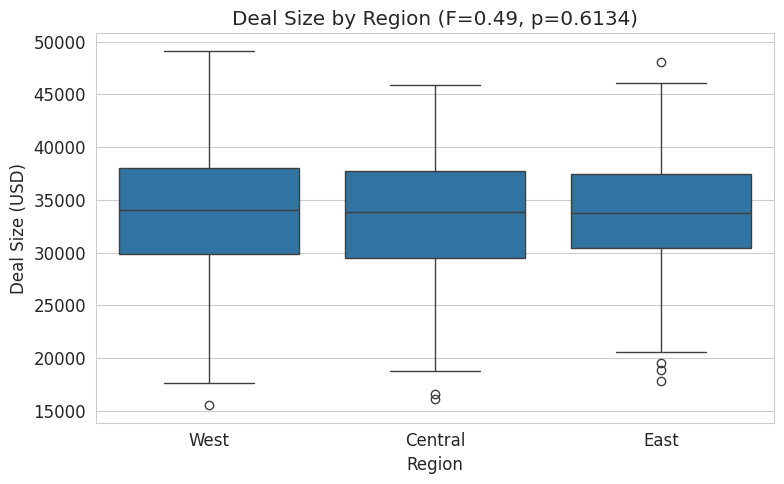

In [ ]:
# ======================================================================
# Q3B — ONE-WAY ANOVA: DEAL SIZE ACROSS THREE REGIONS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   If one sales region is consistently closing larger deals than the
#   others, that's valuable information -- it might mean that region's
#   sales process, territory mix, or rep training should be studied and
#   replicated elsewhere. But before recommending that, James needs to
#   know whether the apparent regional differences are statistically
#   real or just the kind of random variation you'd expect even if all
#   three regions were performing identically.
# ======================================================================

# ── Step 1: State the hypotheses (as a comment, since these are conceptual, not computed) ──
# H0: mu_West = mu_Central = mu_East  (no difference in mean deal size across regions)
# H1: At least one region's mean deal size differs from the others

# ── Step 2: Confirm the region categories present in the data ──
regions = sales_df['Region'].unique()
print(f"Regions in dataset: {regions}")

# ── Step 3: Build one group of deal sizes per region ──
groups = [sales_df[sales_df['Region'] == r]['Deal_Size_USD'] for r in regions]

# ── Step 4: Run the one-way ANOVA across all three groups at once ──
f_stat, p_val = stats.f_oneway(*groups)                      # *groups unpacks the list into separate arguments
print(f"\nANOVA F-statistic: {f_stat:.2f}")
print(f"ANOVA p-value: {p_val:.6f}")

# ── Step 5: Only run Tukey's HSD post-hoc test if the ANOVA was significant ──
if p_val < 0.05:
    tukey = pairwise_tukeyhsd(sales_df['Deal_Size_USD'], sales_df['Region'], alpha=0.05)
    print("\nTukey HSD Post-Hoc Results:")
    print(tukey)
else:
    print("\nANOVA was not statistically significant, so no post-hoc test is run.")
    print("There is no statistical justification for comparing individual region pairs further.")

# ── Step 6: Visualize deal size distribution by region ──
plt.figure(figsize=(8, 5))
sns.boxplot(x='Region', y='Deal_Size_USD', data=sales_df)
plt.title(f'Deal Size by Region (F={f_stat:.2f}, p={p_val:.4f})')
plt.ylabel('Deal Size (USD)')
plt.tight_layout()
plt.savefig('q3b_region_anova_boxplot.png', dpi=150)
plt.show()


### 📝 Your Answer

> Why is ANOVA the correct test here, rather than multiple separate t-tests?
>
> State your conclusion: does region significantly predict deal size in this dataset?
>
> If significant, which regions differ from each other based on the Tukey HSD output?


### Question 3C: Statistical vs. Practical Significance

**Prompt:** Discuss the difference between statistical significance and practical significance in the context of NovaTech's business decisions.

**What to do:**
1. Use a concrete example from the sales data to illustrate the difference (e.g., a small but statistically significant change in average sales cycle length).
2. Compute the percentage improvement and discuss whether it is practically meaningful.

**Deliverables:** Printed calculation; written discussion distinguishing statistical and practical significance, using a NovaTech-specific example.

**Purpose of this cell**

Statistical significance (a low p-value) only tells us that an observed effect is unlikely to be due to random chance. It says nothing about whether the effect is large enough to actually matter for a business decision. This code demonstrates that distinction concretely: we take a small, hypothetical improvement in sales cycle length, show that it could easily be statistically significant with enough data, and then calculate what that improvement actually represents as a percentage of the current average — which is the number that should drive a real decision about whether to invest in a process change.

In [ ]:
# ======================================================================
# Q3C — STATISTICAL VS. PRACTICAL SIGNIFICANCE, WORKED EXAMPLE
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A p-value alone can make a tiny, irrelevant effect look impressive,
#   and large datasets make this worse -- with enough data, almost any
#   nonzero difference becomes 'statistically significant.' Before
#   NovaTech invests time and money rolling out a new sales process
#   company-wide, leadership needs the SIZE of the expected improvement
#   translated into a number they can weigh against the cost of making
#   the change.
# ======================================================================

# ── Step 1: Set up a hypothetical example using NovaTech's actual average cycle length ──
# Suppose a new process is piloted and reduces cycle length by 0.3 days, found to be
# statistically significant at p = 0.01 (a very low, "highly significant" p-value)
mean_diff = 0.3                                          # Hypothetical improvement, in days
avg_cycle = sales_df['Sales_Cycle_Days'].mean()           # NovaTech's actual current average cycle length

# ── Step 2: Compute what this improvement represents as a PERCENTAGE of the current average ──
pct_improvement = (mean_diff / avg_cycle) * 100

print(f"Average sales cycle length (actual data): {avg_cycle:.1f} days")
print(f"Hypothetical improvement: {mean_diff} days")
print(f"Improvement as a percentage of the average: {pct_improvement:.2f}%")
print(f"Practically meaningful? {'Yes' if pct_improvement > 5 else 'Probably not -- the effect is too small to matter operationally'}")

# ── Step 3: Reminder -- always pair statistical results with effect size and dollar/percentage impact ──
print("\nKey takeaway: statistical significance (p < 0.05) tells you a result is")
print("unlikely to be due to chance. Practical significance asks whether the size")
print("of that result is large enough to justify acting on it. Always report both.")


Average sales cycle length (actual data): 53.2 days
Hypothetical improvement: 0.3 days
Improvement as a percentage of the average: 0.56%
Practically meaningful? Probably not -- the effect is too small to matter operationally

Key takeaway: statistical significance (p < 0.05) tells you a result is
unlikely to be due to chance. Practical significance asks whether the size
of that result is large enough to justify acting on it. Always report both.


### 📝 Your Answer

> In your own words, what is the difference between statistical significance and practical significance?
>
> Using the percentage you computed above, is a 0.3-day improvement in sales cycle length practically meaningful for NovaTech? Why or why not?
>
> Give one other example from this case study (your choice) where a statistically significant result might or might not be practically significant.


---

## Question 4: Strategic Recommendations (25 points)

**Prompt:** Synthesize your findings from Questions 1–3 into a data-driven action plan for NovaTech's executive team.

This question is answered primarily in writing (as a separate typed document, per the assignment instructions: *"Upload your responses as a typed document. Label your file as Question 4 (Your Name)"*). The code cell below helps you organize your evidence into a clean summary table, but the heart of Question 4 is the written analysis described below.

**Part A:** Build a data-driven action plan with at least three prioritized recommendations for the executive team. For each recommendation, answer:
- What were the 2–3 most concerning findings from Questions 1–3?
- Which variables actually drive revenue (significant in your regression) vs. which don't (e.g., a predictor with p > 0.05)?
- How much revenue is at risk from churn, declining deal sizes, or wasted marketing spend?
- For each finding, what specific action should be taken, by whom, and by when? How will you measure success? How do you rank the recommendations (consider revenue impact, implementation cost, and strength of evidence)?

**Part B:** For each recommendation, answer:
- What specific statistic from your analysis supports this recommendation? (Cite the number.)
- What doesn't the data tell you? (Confounders, missing variables, unexplained variance in R²?)
- What could go wrong if management acts on this recommendation, and how would you mitigate that risk?

**Part C:** Discuss how to present these findings to non-technical executives:
- What is the single best chart for each finding (line for trends, bar for comparisons, scatter for relationships)?
- Does each chart title state the takeaway, not just the variable name?
- Are you leading with business impact, not methodology (e.g., “We're losing \$2.1M to churn” rather than “Our t-test yielded p = 0.0002”)?
- Can you handle likely pushback: “How confident are you?”, “What's the ROI?”, “Can we test this first?”

**Deliverables:** A separate typed document (not this notebook) containing your written action plan, organized as Parts A, B, and C above. The code cell below is optional scaffolding to help you organize your evidence before you write that document.

**Purpose of this cell**

This is optional scaffolding, not a required deliverable in itself. Building a structured table here — priority, recommendation, supporting data evidence, and risk/limitation — can help you organize your thinking before you write the Question 4 document. The actual graded deliverable for Question 4 is the typed document described above, not this notebook cell.

In [ ]:
# ======================================================================
# Q4 — OPTIONAL SCAFFOLDING: ORGANIZING YOUR RECOMMENDATIONS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Executives rarely have time to read a full statistical report. A
#   one-page table that ties each recommendation directly to a specific
#   piece of evidence (and is honest about the risk of being wrong) is
#   what actually gets read, discussed, and acted on in a real
#   boardroom. Building this table forces you to make sure every
#   recommendation you propose is actually backed by something you
#   found in Questions 1–3 -- not just a generic best practice.
# ======================================================================

# ── This is a TEMPLATE you should fill in with YOUR OWN findings from Q1-Q3 ──
# Replace the placeholder text below with your actual recommendations, evidence, and risks.

recommendations = pd.DataFrame({
    'Priority': [1, 2, 3],
    'Recommendation': [
        '[YOUR RECOMMENDATION 1 -- replace this text]',
        '[YOUR RECOMMENDATION 2 -- replace this text]',
        '[YOUR RECOMMENDATION 3 -- replace this text]',
    ],
    'Data_Evidence': [
        '[Cite a specific statistic from your Q1-Q3 analysis]',
        '[Cite a specific statistic from your Q1-Q3 analysis]',
        '[Cite a specific statistic from your Q1-Q3 analysis]',
    ],
    'Risk_or_Limitation': [
        '[What could go wrong, or what the data does not tell you]',
        '[What could go wrong, or what the data does not tell you]',
        '[What could go wrong, or what the data does not tell you]',
    ]
})

print(recommendations.to_string(index=False))

# ── Optional: save this table as a CSV to reference while writing your Question 4 document ──
recommendations.to_csv('q4_recommendations_draft.csv', index=False)


 Priority                               Recommendation                                        Data_Evidence                                        Risk_or_Limitation
        1 [YOUR RECOMMENDATION 1 -- replace this text] [Cite a specific statistic from your Q1-Q3 analysis] [What could go wrong, or what the data does not tell you]
        2 [YOUR RECOMMENDATION 2 -- replace this text] [Cite a specific statistic from your Q1-Q3 analysis] [What could go wrong, or what the data does not tell you]
        3 [YOUR RECOMMENDATION 3 -- replace this text] [Cite a specific statistic from your Q1-Q3 analysis] [What could go wrong, or what the data does not tell you]


### 📝 Your Answer

> This is a reminder, not a question: Question 4 must be submitted as a SEPARATE TYPED DOCUMENT, labeled 'Question 4 (Your Name)', not as a cell in this notebook.
>
> Use the table above as a working draft, but write your full Part A / Part B / Part C response in that separate document, addressing every bullet point listed in the prompt above.
>

(No response needed in this cell — this is a reminder about the separate Question 4 submission.)


---

# Case Study 2: Healthcare Administration

## "Reducing Readmissions at Mercy Regional Medical Center"

**Background:** Mercy Regional Medical Center is a 380-bed acute care hospital in a mid-sized metropolitan area serving a diverse patient population. In 2025, the hospital's 30-day all-cause readmission rate rose to 18.4%, exceeding the national benchmark of 15.2% and triggering CMS financial penalties under the Hospital Readmissions Reduction Program (HRRP), projected to cost Mercy \$2.1 million in reduced Medicare reimbursements this fiscal year. Chief Quality Officer Dr. Priya Sharma has assembled a task force and hired healthcare data analyst Kenji Watanabe to lead a data-driven investigation.

**Datasets used in this section** (loaded from the actual CSV files provided for this course):

| File | Contents |
|---|---|
| `healthcare_patient_records.csv` | 12,400 discharge records: demographics, clinical data, follow-up completion, medication reconciliation, 30-day readmission outcome |
| `healthcare_staffing_data.csv` | 18 months of nurse-to-patient ratios across 4 departments |

**If you are a Healthcare Administration major, complete this entire section. If not, skip to the section that matches your major.**


**Purpose of this cell**

We load the two healthcare datasets and inspect their structure before doing anything else, exactly as we did for the business case study. Healthcare data carries extra responsibility: errors here don't just cost money, they can lead to misallocated clinical resources, so confirming the data is what we expect before analyzing it matters even more in this context.

In [ ]:
# ======================================================================
# LOAD AND INSPECT THE HEALTHCARE DATASETS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Dr. Sharma's task force has a fixed three-month window to deliver
#   findings to the hospital board. Before Kenji can tell the board
#   anything about WHY readmissions are high, he must first confirm
#   exactly what the 12,400-record patient dataset actually contains --
#   which columns exist, how they're coded, and whether the data covers
#   the time period and patient population the board expects.
# ======================================================================

# ── Step 1: Load each CSV file into its own pandas DataFrame ──
patients_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/healthcare_patient_records.csv')   # 12,400 individual discharge records
staffing_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/healthcare_staffing_data.csv')      # 18 months of nurse staffing data by unit

# ── Step 2: Confirm the shape (rows, columns) of each dataset ──
print("Patient Records:", patients_df.shape, "rows, columns")
print("Staffing Data:  ", staffing_df.shape, "rows, columns")

# ── Step 3: Look at the actual column names ──
print("\nPatient Records columns:", list(patients_df.columns))
print("Staffing Data columns:", list(staffing_df.columns))

# ── Step 4: Preview the first 5 rows of the patient records dataset ──
patients_df.head()


Patient Records: (12400, 17) rows, columns
Staffing Data:   (72, 6) rows, columns

Patient Records columns: ['Patient_ID', 'Age', 'Gender', 'Race_Ethnicity', 'Insurance_Type', 'Department', 'Chronic_Conditions_Count', 'Length_of_Stay_Days', 'ICU_Admission', 'Num_Procedures', 'Weekend_Discharge', 'Discharge_Disposition', 'Followup_Completed', 'Days_to_Followup', 'Med_Reconciliation_Completed', 'Readmitted_30Day', 'Days_to_Readmission']
Staffing Data columns: ['Month', 'Unit', 'Nurse_to_Patient_Ratio', 'Day_Shift_Nurses', 'Night_Shift_Nurses', 'Weekend_Coverage_Pct']


,Patient_ID,Age,Gender,Race_Ethnicity,Insurance_Type,Department,Chronic_Conditions_Count,Length_of_Stay_Days,ICU_Admission,Num_Procedures,Weekend_Discharge,Discharge_Disposition,Followup_Completed,Days_to_Followup,Med_Reconciliation_Completed,Readmitted_30Day,Days_to_Readmission
0,P-00001,50,Female,Hispanic,Private,General_Medicine,2,2,No,3,No,SNF,Yes,5.0000,Yes,No,NaN
1,P-00002,78,Male,Black,Medicare,General_Medicine,3,6,No,3,No,Home_Health,Yes,14.0000,Yes,No,NaN
2,P-00003,64,Male,Other,Medicare,Cardiology,2,1,No,1,No,Home,Yes,18.0000,No,No,NaN
3,P-00004,68,Male,Hispanic,Medicare,Cardiology,2,5,Yes,4,Yes,Home,No,NaN,Yes,No,NaN
4,P-00005,36,Female,White,Medicare,Cardiology,3,1,No,1,No,Home,Yes,10.0000,No,No,NaN


**Purpose of this cell**

Most of the statistical functions we will use throughout this section — correlation, t-tests, regression — require numeric input, not text labels like "Yes" and "No". This cell converts the key Yes/No columns in the patient records into clean 0/1 numeric flags, once, right after loading the data, so that every later calculation in this notebook can reference the same consistent columns without repeating this conversion each time.

In [ ]:
# ======================================================================
# CREATE A NUMERIC READMISSION FLAG FOR ANALYSIS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Most of the statistical functions we'll use (correlation, t-tests,
#   regression) require numbers, not text labels like 'Yes' and 'No'.
#   Converting Readmitted_30Day into a clean 0/1 flag up front means
#   every later calculation in this notebook can reference the same
#   consistent column without re-doing this conversion each time.
# ======================================================================

# ── Step 1: Convert the Yes/No readmission column into a 0/1 numeric flag ──
# 1 = readmitted within 30 days, 0 = not readmitted
patients_df['Readmit_Flag'] = (patients_df['Readmitted_30Day'] == 'Yes').astype(int)

# ── Step 2: Do the same for the other Yes/No clinical flags we'll need later ──
patients_df['Followup_Flag'] = (patients_df['Followup_Completed'] == 'Yes').astype(int)
patients_df['MedRecon_Flag'] = (patients_df['Med_Reconciliation_Completed'] == 'Yes').astype(int)
patients_df['Weekend_Flag'] = (patients_df['Weekend_Discharge'] == 'Yes').astype(int)

# ── Step 3: Quick sanity check -- print the overall readmission rate ──
print(f"Overall hospital readmission rate: {patients_df['Readmit_Flag'].mean()*100:.1f}%")
print(f"Overall follow-up completion rate: {patients_df['Followup_Flag'].mean()*100:.1f}%")
print(f"Overall medication reconciliation completion rate: {patients_df['MedRecon_Flag'].mean()*100:.1f}%")
print(f"Percent of discharges on a weekend: {patients_df['Weekend_Flag'].mean()*100:.1f}%")


Overall hospital readmission rate: 10.0%
Overall follow-up completion rate: 58.2%
Overall medication reconciliation completion rate: 64.1%
Percent of discharges on a weekend: 28.4%


---

## Question 1: Descriptive and Exploratory Analysis (25 points)

### Question 1A: Readmission Rate Variation Across Departments

**Prompt:** Analyze the readmission rate variation across departments. What does this tell Dr. Sharma about where to focus intervention resources?

**What to do:**
1. Calculate the readmission rate for each department.
2. Calculate the overall hospital readmission rate for comparison.
3. Calculate total readmissions per department (volume, not just rate).
4. Create a bar chart with the 15.2% national benchmark as a reference line.

**Deliverables:** One visualization saved as `dept_readmission_rates.png`; printed department summary table; written interpretation.

**Purpose of this cell**

This code builds the core diagnostic table for the entire healthcare case: readmission rate, patient volume, and total readmissions for each of the four departments, compared directly against the 15.2% national CMS benchmark. We deliberately compute both the *rate* (percentage) and the *volume* (raw count) for each department, because a department with a high rate but very few total patients represents a much smaller problem in absolute terms than a department with a more moderate rate but a huge patient volume.

Department Readmission Summary:
         Department  total_patients  total_readmitted  readmission_rate  \
0        Cardiology            3028               394            0.1300   
3       Pulmonology            2427               266            0.1100   
1  General_Medicine            4416               414            0.0900   
2       Orthopedics            2529               165            0.0700   

   readmission_rate_pct  vs_benchmark  
0               13.0100       -2.1900  
3               10.9600       -4.2400  
1                9.3800       -5.8200  
2                6.5200       -8.6800  

Hospital-wide overall readmission rate: 10.0%
National CMS benchmark: 15.2%


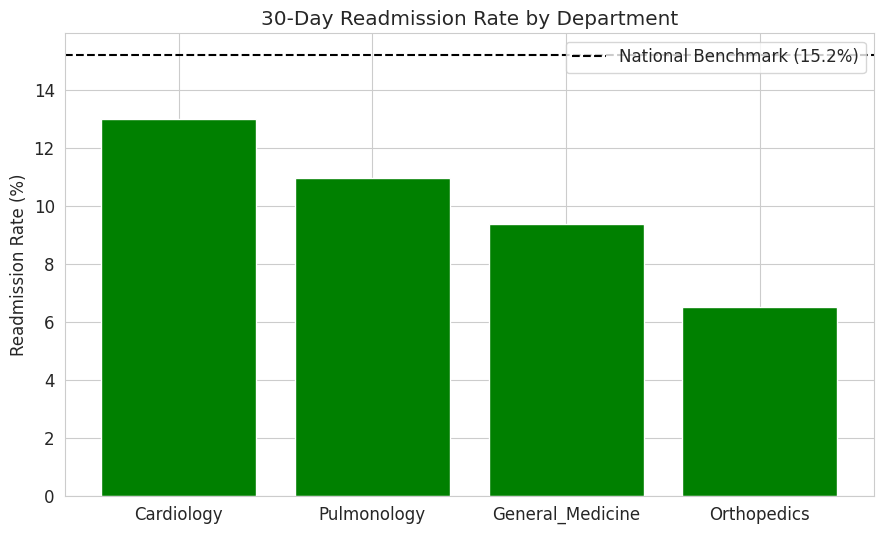

In [ ]:
# ======================================================================
# Q1A — READMISSION RATE BY DEPARTMENT VS. NATIONAL BENCHMARK
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Mercy Regional is losing $2.1 million in CMS penalties, and
#   intervention resources -- extra discharge planning staff, follow-up
#   phone calls, care coordinators -- are not unlimited. Dr. Sharma
#   needs a clear, data-backed answer to a single question: which
#   department, if we fixed it first, would move the hospital's overall
#   readmission rate the most? Rate alone can be misleading if patient
#   volume differs a lot by department, so we report both.
# ======================================================================

# ── Step 1: Compute readmission rate, patient count, and total readmissions per department ──
dept_summary = patients_df.groupby('Department').agg(
    total_patients=('Patient_ID', 'count'),                # How many patients were discharged from this department
    total_readmitted=('Readmit_Flag', 'sum'),                # How many of those patients were readmitted within 30 days
    readmission_rate=('Readmit_Flag', 'mean')                 # Readmitted / total = the rate, as a decimal (e.g. 0.13 = 13%)
).reset_index()

dept_summary['readmission_rate_pct'] = dept_summary['readmission_rate'] * 100    # Convert to a percentage for readability
dept_summary['vs_benchmark'] = dept_summary['readmission_rate_pct'] - 15.2        # Positive = worse than benchmark, negative = better

# ── Step 2: Sort departments from worst to best readmission rate ──
dept_summary = dept_summary.sort_values('readmission_rate_pct', ascending=False)
print("Department Readmission Summary:")
print(dept_summary.round(2))

# ── Step 3: Print the overall hospital-wide readmission rate for context ──
overall_rate = patients_df['Readmit_Flag'].mean() * 100
print(f"\nHospital-wide overall readmission rate: {overall_rate:.1f}%")
print(f"National CMS benchmark: 15.2%")

# ── Step 4: Bar chart of department rates, color-coded against the benchmark ──
benchmark = 15.2
plt.figure(figsize=(9, 5.5))
bar_colors = ['red' if rate > benchmark else 'green' for rate in dept_summary['readmission_rate_pct']]
plt.bar(dept_summary['Department'], dept_summary['readmission_rate_pct'], color=bar_colors)
plt.axhline(y=benchmark, color='black', linestyle='--', label=f'National Benchmark ({benchmark}%)')
plt.title('30-Day Readmission Rate by Department')
plt.ylabel('Readmission Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('dept_readmission_rates.png', dpi=150)             # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> Which departments exceed the 15.2% national benchmark, and by how much?
>
> Based on both rate AND volume, where should Dr. Sharma focus intervention resources first, and why?
>


### Question 1B: Weekend vs. Weekday Discharge Disparity

**Prompt:** The weekend versus weekday discharge disparity is striking. Using descriptive statistics, explain what factors might contribute to this gap.

**What to do:**
1. Calculate the readmission rate separately for weekend and weekday discharges.
2. Compare descriptive statistics between the two groups for length of stay, chronic conditions, follow-up completion rate, and medication reconciliation rate.
3. Create a grouped bar chart comparing key metrics.

**Deliverables:** One visualization saved as `weekend_vs_weekday_comparison.png`; printed comparison tables; written interpretation.

**Purpose of this cell**

This code investigates a specific, narrower question than 1A: does the *day of the week* a patient is discharged matter for their readmission risk, independent of which department they're in? We compare weekend and weekday discharges across several clinical variables at once — not just readmission rate itself, but also length of stay, chronic conditions, and the two process variables (follow-up completion and medication reconciliation) that the hospital can actually control operationally.

Comparing multiple variables side by side like this helps distinguish between two very different explanations for a weekend effect: a *staffing/process* explanation (e.g., fewer staff available on weekends to do proper discharge planning) versus a *patient mix* explanation (e.g., sicker patients happen to be discharged on weekends for unrelated reasons).

Weekend discharges: n = 3522, readmission rate = 11.2%
Weekday discharges: n = 8878, readmission rate = 9.5%

Weekend vs. Weekday Clinical Comparison:
                          Weekend_Mean  Weekday_Mean  Difference
Length_of_Stay_Days             4.3900        4.5280     -0.1380
Chronic_Conditions_Count        2.4820        2.4760      0.0060
Followup_Flag                   0.5760        0.5840     -0.0080
MedRecon_Flag                   0.6400        0.6410     -0.0010

Weekend Discharge Volume by Department:
                  weekend_discharge_count  weekend_discharge_rate
Department                                                       
Cardiology                            818                  0.2700
General_Medicine                     1276                  0.2890
Orthopedics                           719                  0.2840
Pulmonology                           709                  0.2920


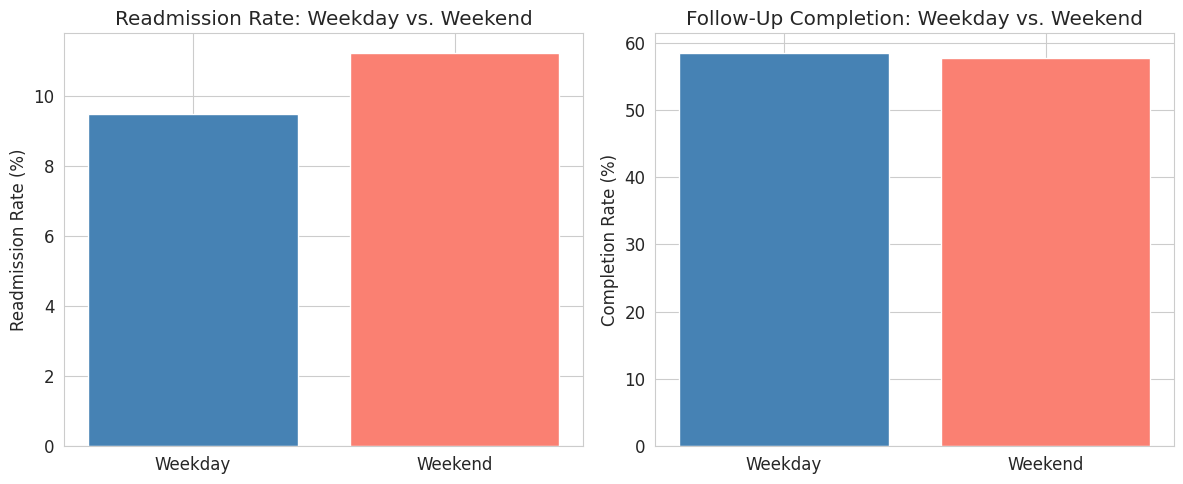

In [ ]:
# ======================================================================
# Q1B — WEEKEND VS. WEEKDAY DISCHARGE COMPARISON
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   If weekend discharges are riskier mainly because of reduced weekend
#   staffing or rushed discharge processes, that points to an
#   operational fix Dr. Sharma can implement directly -- like weekend
#   care coordinator coverage. If instead it's explained by which
#   PATIENTS happen to be discharged on weekends, the fix looks
#   completely different. This comparison is the first step in telling
#   those two explanations apart.
# ======================================================================

# ── Step 1: Split patients into weekend and weekday discharge groups ──
weekend = patients_df[patients_df['Weekend_Flag'] == 1]
weekday = patients_df[patients_df['Weekend_Flag'] == 0]

print(f"Weekend discharges: n = {len(weekend)}, readmission rate = {weekend['Readmit_Flag'].mean()*100:.1f}%")
print(f"Weekday discharges: n = {len(weekday)}, readmission rate = {weekday['Readmit_Flag'].mean()*100:.1f}%")

# ── Step 2: Compare several clinical variables between the two groups ──
compare_vars = ['Length_of_Stay_Days', 'Chronic_Conditions_Count', 'Followup_Flag', 'MedRecon_Flag']

comparison = pd.DataFrame()
for v in compare_vars:
    comparison.loc[v, 'Weekend_Mean'] = weekend[v].mean()
    comparison.loc[v, 'Weekday_Mean'] = weekday[v].mean()
    comparison.loc[v, 'Difference'] = weekend[v].mean() - weekday[v].mean()

print("\nWeekend vs. Weekday Clinical Comparison:")
print(comparison.round(3))

# ── Step 3: Department breakdown of weekend discharge volume ──
weekend_by_dept = patients_df.groupby('Department')['Weekend_Flag'].agg(['sum', 'mean'])
weekend_by_dept.columns = ['weekend_discharge_count', 'weekend_discharge_rate']
print("\nWeekend Discharge Volume by Department:")
print(weekend_by_dept.round(3))

# ── Step 4: Grouped bar chart -- readmission and follow-up rate, weekend vs. weekday ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Weekday', 'Weekend'],
            [weekday['Readmit_Flag'].mean()*100, weekend['Readmit_Flag'].mean()*100],
            color=['steelblue', 'salmon'])
axes[0].set_title('Readmission Rate: Weekday vs. Weekend')
axes[0].set_ylabel('Readmission Rate (%)')

axes[1].bar(['Weekday', 'Weekend'],
            [weekday['Followup_Flag'].mean()*100, weekend['Followup_Flag'].mean()*100],
            color=['steelblue', 'salmon'])
axes[1].set_title('Follow-Up Completion: Weekday vs. Weekend')
axes[1].set_ylabel('Completion Rate (%)')

plt.tight_layout()
plt.savefig('weekend_vs_weekday_comparison.png', dpi=150)      # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> What does the comparison table reveal about differences between weekend and weekday discharges?
>
> Propose 2–3 contributing factors that might explain the weekend/weekday readmission gap.


### Question 1C: Profiling Patients Who Miss Follow-Up

**Prompt:** Only a little over half of patients completed follow-up within 14 days. Describe how you would use demographic and clinical data to create a profile of patients most likely to miss follow-up.

**What to do:**
1. Confirm the overall follow-up completion rate.
2. Calculate follow-up rates by age group, gender, race/ethnicity, insurance type, department, and weekend discharge.
3. Identify subgroups with the lowest follow-up rates.
4. Create a chart of follow-up rates by key categories.

**Deliverables:** One visualization saved as `followup_profile_analysis.png`; printed summary tables; written interpretation.

**Purpose of this cell**

This code builds a multi-dimensional profile of who is and isn't completing follow-up care, breaking the patient population down by several demographic and operational categories at once. The goal is not just to confirm *that* a follow-up gap exists, but to find out *which specific patient subgroups* have the lowest completion rates, since that's the information a hospital's outreach team would need to design a targeted intervention (for example, additional reminder calls or transportation assistance for a specific group) rather than a generic, one-size-fits-all campaign.

Overall follow-up completion rate: 58.2%

Follow-Up Completion Rate by Insurance Type:
Insurance_Type
Medicaid   57.3000
Medicare   58.5000
Private    57.9000
Self-Pay   59.8000
Name: Followup_Flag, dtype: float64

Follow-Up Completion Rate by Department:
Department
Cardiology         59.1000
General_Medicine   57.5000
Orthopedics        57.3000
Pulmonology        59.4000
Name: Followup_Flag, dtype: float64

Follow-Up Completion Rate by Discharge Day Type:
Weekend_Discharge
No    58.4000
Yes   57.6000
Name: Followup_Flag, dtype: float64

Follow-Up Completion Rate by Race/Ethnicity:
Race_Ethnicity
Asian      57.7000
Black      59.0000
Hispanic   58.3000
Other      55.3000
White      58.2000
Name: Followup_Flag, dtype: float64

Average days to follow-up (completers only): 11.4 days


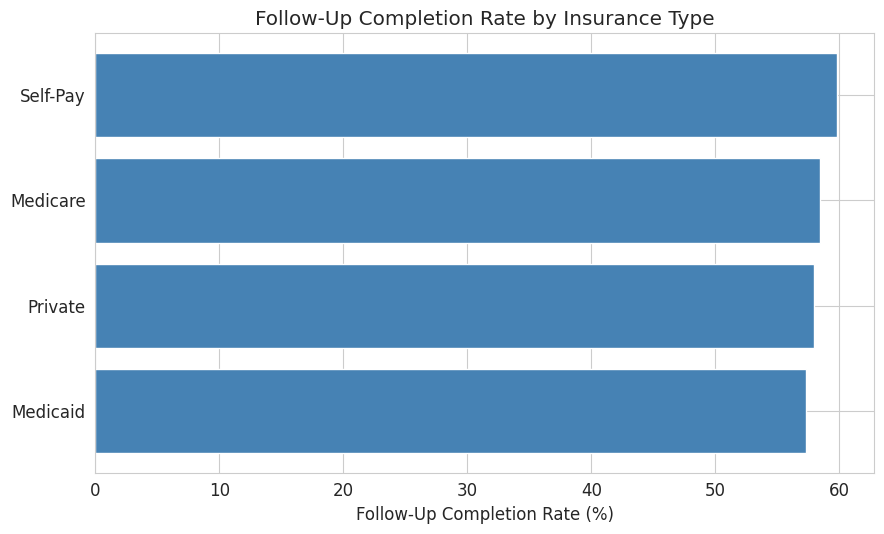

In [ ]:
# ======================================================================
# Q1C — PROFILING PATIENTS LIKELY TO MISS FOLLOW-UP CARE
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Missed follow-up appointments are one of the few readmission risk
#   factors a hospital can directly intervene on -- through reminder
#   calls, transportation vouchers, or telehealth options. But a
#   generic 'call everyone' outreach program is expensive and
#   inefficient. Knowing which specific patient groups are least
#   likely to complete follow-up lets the hospital target its limited
#   outreach staff and budget where it will have the largest impact.
# ======================================================================

# ── Step 1: Confirm the overall follow-up completion rate ──
overall_followup_rate = patients_df['Followup_Flag'].mean() * 100
print(f"Overall follow-up completion rate: {overall_followup_rate:.1f}%")

# ── Step 2: Follow-up rate by insurance type ──
followup_by_insurance = patients_df.groupby('Insurance_Type')['Followup_Flag'].mean() * 100
print("\nFollow-Up Completion Rate by Insurance Type:")
print(followup_by_insurance.round(1))

# ── Step 3: Follow-up rate by department ──
followup_by_dept = patients_df.groupby('Department')['Followup_Flag'].mean() * 100
print("\nFollow-Up Completion Rate by Department:")
print(followup_by_dept.round(1))

# ── Step 4: Follow-up rate by weekend vs. weekday discharge ──
followup_by_weekend = patients_df.groupby('Weekend_Discharge')['Followup_Flag'].mean() * 100
print("\nFollow-Up Completion Rate by Discharge Day Type:")
print(followup_by_weekend.round(1))

# ── Step 5: Follow-up rate by race/ethnicity ──
followup_by_race = patients_df.groupby('Race_Ethnicity')['Followup_Flag'].mean() * 100
print("\nFollow-Up Completion Rate by Race/Ethnicity:")
print(followup_by_race.round(1))

# ── Step 6: Average days to follow-up for patients who DID complete it ──
completers = patients_df[patients_df['Followup_Flag'] == 1]
print(f"\nAverage days to follow-up (completers only): {completers['Days_to_Followup'].mean():.1f} days")

# ── Step 7: Horizontal bar chart of follow-up rates by insurance type ──
plt.figure(figsize=(9, 5.5))
followup_by_insurance_sorted = followup_by_insurance.sort_values()
plt.barh(followup_by_insurance_sorted.index, followup_by_insurance_sorted.values, color='steelblue')
plt.xlabel('Follow-Up Completion Rate (%)')
plt.title('Follow-Up Completion Rate by Insurance Type')
plt.tight_layout()
plt.savefig('followup_profile_analysis.png', dpi=150)          # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> Which subgroups (by insurance type, department, weekend discharge, or race/ethnicity) have the lowest follow-up completion rates?
>
> Describe the profile of a patient "at risk" for missing follow-up, based on your tables above.
>
> What targeted outreach recommendation follows from this profile?



---

## Question 2: Correlation and Regression Analysis (25 points)

### Question 2A: Medication Reconciliation Correlation

**Prompt:** Interpret the correlation between medication reconciliation and readmissions (reported as r = –0.74 at the unit level in the case background). What are the implications for hospital policy, and what are the limitations?

**What to do:**
1. Calculate the patient-level correlation between `MedRecon_Flag` and `Readmit_Flag`.
2. Aggregate at the department level and calculate the department-level correlation.
3. Create a scatter plot with a trend line.

**Deliverables:** Patient-level and department-level correlation coefficients; scatter plot saved as a `.png`; written interpretation.

**Purpose of this cell**

An important methodological subtlety appears in this question: correlations can look very different depending on the *level* at which you compute them. At the individual patient level, medication reconciliation is a 0/1 flag and readmission is a 0/1 flag, so the correlation captures patient-by-patient variation. At the department level, we first aggregate to a reconciliation *rate* and a readmission *rate* per department, which captures a coarser, department-to-department pattern. The case background's reported r = –0.74 is described as a unit-level correlation, so we compute both so you can see how the same underlying data tells a different statistical story depending on aggregation level.

Patient-level correlation: r = 0.0000, p = 0.997968

Department-Level Rates:
         Department  medrecon_rate  readmit_rate
0        Cardiology         0.6330        0.1300
1  General_Medicine         0.6400        0.0940
2       Orthopedics         0.6450        0.0650
3       Pulmonology         0.6460        0.1100

Department-level correlation: r = -0.6634, p = 0.3366 (n = 4 departments)


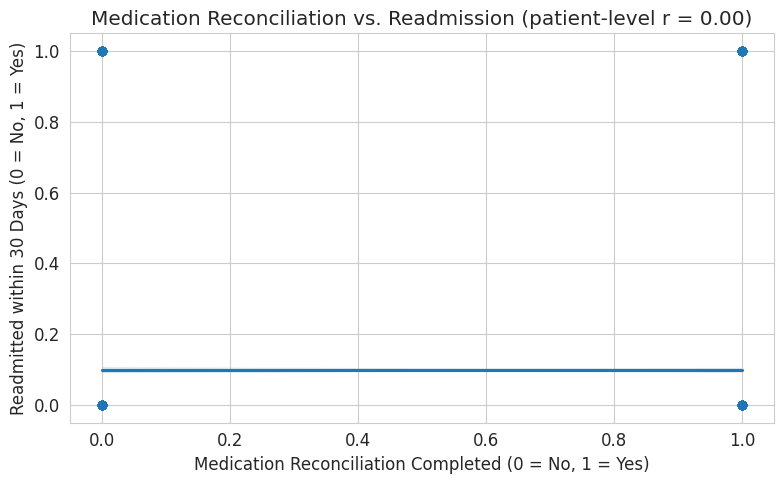

In [ ]:
# ======================================================================
# Q2A — MEDICATION RECONCILIATION VS. READMISSION CORRELATION
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Medication reconciliation -- the process of verifying a patient's
#   complete medication list at discharge to catch dangerous errors or
#   omissions -- is a process the hospital fully controls and can scale
#   up with staffing and protocol changes. If it's strongly related to
#   readmission risk, that's an actionable, relatively low-cost policy
#   lever for Dr. Sharma compared to harder-to-change factors like
#   patient demographics.
# ======================================================================

# ── Step 1: Compute the PATIENT-LEVEL correlation ──
r_patient, p_patient = stats.pearsonr(patients_df['MedRecon_Flag'], patients_df['Readmit_Flag'])
print(f"Patient-level correlation: r = {r_patient:.4f}, p = {p_patient:.6f}")

# ── Step 2: Aggregate to the DEPARTMENT level and compute the correlation there ──
# First, build a department-level rate table (analogous to "unit-level" in the case background)
dept_rates = patients_df.groupby('Department').agg(
    medrecon_rate=('MedRecon_Flag', 'mean'),
    readmit_rate=('Readmit_Flag', 'mean')
).reset_index()

print("\nDepartment-Level Rates:")
print(dept_rates.round(3))

r_dept, p_dept = stats.pearsonr(dept_rates['medrecon_rate'], dept_rates['readmit_rate'])
print(f"\nDepartment-level correlation: r = {r_dept:.4f}, p = {p_dept:.4f} (n = {len(dept_rates)} departments)")

# ── Step 3: Scatter plot of the patient-level relationship with a regression line ──
plt.figure(figsize=(8, 5))
sns.regplot(x='MedRecon_Flag', y='Readmit_Flag', data=patients_df,
            scatter_kws={'alpha': 0.15}, logistic=False)        # alpha low because many points overlap at 0/1
plt.title(f'Medication Reconciliation vs. Readmission (patient-level r = {r_patient:.2f})')
plt.xlabel('Medication Reconciliation Completed (0 = No, 1 = Yes)')
plt.ylabel('Readmitted within 30 Days (0 = No, 1 = Yes)')
plt.tight_layout()
plt.savefig('medrecon_readmission_scatter.png', dpi=150)        # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> Compare your patient-level and department-level correlation results. Do they tell a similar or different story?
>
> What are the policy implications for Mercy Regional if this relationship is real?
>
> What are 2 limitations of using this correlation to justify a hospital policy change?


### Question 2B: Multiple Regression Equation and Interpretation

**Prompt:** Using your regression output, write the regression equation and interpret each coefficient in clinical terms.

**What to do:**
1. Define the dependent variable (`Readmit_Flag`) and four predictors: `Length_of_Stay_Days`, `Chronic_Conditions_Count`, `Followup_Flag`, `Weekend_Flag`.
2. Fit an OLS regression using `statsmodels`.
3. Print the full regression summary and write out the equation.

**Deliverables:** Full `model.summary()` output; written regression equation; coefficient interpretation table; written narrative.

**Purpose of this cell**

This is the central regression model for the healthcare case, predicting the 30-day readmission flag from four clinical and operational variables: how long the patient stayed in the hospital, how many chronic conditions they have, whether they completed follow-up care, and whether they were discharged on a weekend. Note that we are using a linear regression (OLS) on a binary 0/1 outcome here, exactly as the assignment template specifies — this is sometimes called a 'linear probability model.' It's simpler to interpret than logistic regression (each coefficient is directly a change in probability), though it has known statistical limitations your instructor may want you to discuss.

In [ ]:
# ======================================================================
# Q2B — MULTIPLE REGRESSION: PREDICTING 30-DAY READMISSION
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   This model lets Kenji answer a precise question for the hospital
#   board: of everything that varies patient to patient, which factors
#   are statistically reliable predictors of readmission, and how big
#   is each effect? That distinction matters enormously for budgeting --
#   the hospital should invest first in the levers with the strongest,
#   most reliable statistical backing, not just the ones that sound
#   intuitively important.
# ======================================================================

# ── Step 1: Define the independent variables (X) and dependent variable (y) ──
X_cols = ['Length_of_Stay_Days', 'Chronic_Conditions_Count', 'Followup_Flag', 'Weekend_Flag']
X = patients_df[X_cols]
y = patients_df['Readmit_Flag']

# ── Step 2: Add a constant (intercept) and fit the OLS regression ──
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()

# ── Step 3: Print the full statistical summary ──
print(model.summary())

# ── Step 4: Write out the regression equation using the actual fitted coefficients ──
coeffs = model.params
equation = f"Readmission Probability = {coeffs['const']:.4f}"
for var in X_cols:
    sign = '+' if coeffs[var] >= 0 else '-'
    equation += f" {sign} {abs(coeffs[var]):.4f} × {var}"
print("\nRegression Equation:")
print(equation)

# ── Step 5: Build a clean coefficient summary table ──
results_table = pd.DataFrame({
    'Coefficient': model.params,
    'Std_Error': model.bse,
    'p_value': model.pvalues,
    'Significant_at_0.05': model.pvalues < 0.05
})
print("\nCoefficient Summary Table:")
print(results_table.round(4))


                            OLS Regression Results                            
Dep. Variable:           Readmit_Flag   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.040
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.17e-05
Time:                        17:24:21   Log-Likelihood:                -2647.1
No. Observations:               12400   AIC:                             5304.
Df Residuals:                   12395   BIC:                             5341.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

### 📝 Your Answer

> Write out the regression equation using your actual fitted coefficients (you can copy it from the output above).
>
> Interpret each of the four coefficients in plain clinical language a hospital administrator (not a statistician) would understand.
>
> What does your model's R² mean for budgeting and planning at Mercy Regional?


### Question 2C & 2D: Follow-Up Impact and Model Improvement

**Part C Prompt:** The Follow-Up Completion variable may have one of the larger coefficients in your model. Explain what this means for readmission risk and how the hospital should respond.

**Part D Prompt:** What does your model's R² imply about what it captures vs. misses? Suggest two additional variables.

**What to do:**
1. Extract the follow-up coefficient and its 95% confidence interval.
2. Build a scenario analysis: projected readmission rates if follow-up completion improved from its current rate to a target rate (e.g., 85%).
3. Compute VIF for the model's predictors and build a correlation heatmap.

**Deliverables:** Follow-up coefficient with 95% CI; scenario analysis table; VIF table and correlation heatmap; written narrative covering both Part C and Part D.

**Purpose of this cell**

This code does two related things. First, it isolates the follow-up completion coefficient specifically and uses it to build a simple scenario analysis: if the hospital could raise follow-up completion from its current rate to a higher target rate (the case study background uses 58% → 85% as an example), what reduction in readmissions would the model predict? This kind of 'what-if' calculation is exactly the bridge between a regression coefficient and a concrete operational target a hospital can set.

Second, it runs the same VIF and correlation-heatmap multicollinearity check we ran for the business case, applied to this model's four predictors, plus prompts you to think about what's missing from the model given the R-squared value.

Follow-Up Completion coefficient: -0.0045
P-value: 0.412547
95% Confidence Interval: [-0.0152, 0.0062]

Current follow-up completion rate: 58.2%

Scenario Analysis -- Projected Readmission Impact:
  If follow-up reaches 60%: estimated readmission rate change = -0.01 percentage points
  If follow-up reaches 70%: estimated readmission rate change = -0.05 percentage points
  If follow-up reaches 80%: estimated readmission rate change = -0.10 percentage points
  If follow-up reaches 85%: estimated readmission rate change = -0.12 percentage points
  If follow-up reaches 90%: estimated readmission rate change = -0.14 percentage points

Variance Inflation Factor by Predictor:
                   Variable    VIF
3              Weekend_Flag 1.0003
0       Length_of_Stay_Days 1.0003
2             Followup_Flag 1.0001
1  Chronic_Conditions_Count 1.0001


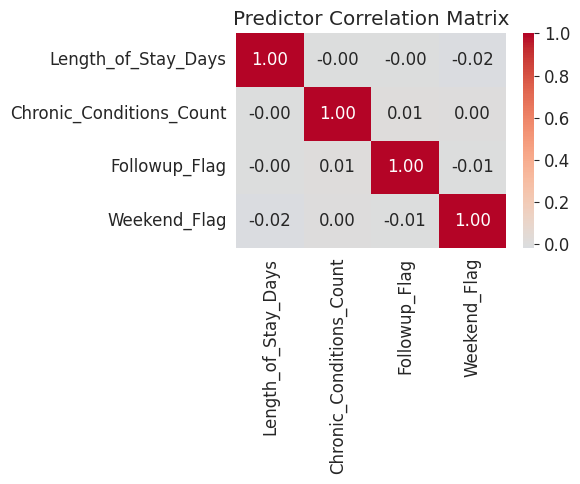

In [ ]:
# ======================================================================
# Q2C/2D — FOLLOW-UP IMPACT SCENARIO AND MODEL DIAGNOSTICS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A regression coefficient by itself ('follow-up completion reduces
#   readmission probability by X') is hard for a hospital board to act
#   on directly. Translating that coefficient into a concrete scenario --
#   'if we raise follow-up completion from 58% to 85%, we project Y
#   fewer readmissions' -- turns an abstract statistic into a target the
#   Chief Quality Officer can actually put in a strategic plan and
#   track progress against.
# ======================================================================

# ── Step 1: Isolate the follow-up completion coefficient and its confidence interval ──
coef_followup = model.params['Followup_Flag']
p_followup = model.pvalues['Followup_Flag']
conf_followup = model.conf_int().loc['Followup_Flag']

print(f"Follow-Up Completion coefficient: {coef_followup:.4f}")
print(f"P-value: {p_followup:.6f}")
print(f"95% Confidence Interval: [{conf_followup[0]:.4f}, {conf_followup[1]:.4f}]")

# ── Step 2: Scenario analysis -- project readmission rate at different follow-up levels ──
current_followup_rate = patients_df['Followup_Flag'].mean()
target_rates = [0.60, 0.70, 0.80, 0.85, 0.90]

print(f"\nCurrent follow-up completion rate: {current_followup_rate*100:.1f}%")
print("\nScenario Analysis -- Projected Readmission Impact:")
for target in target_rates:
    improvement = target - current_followup_rate
    # The coefficient tells us the change in readmission PROBABILITY per 1-unit change in follow-up
    # Since follow-up is 0/1, "improvement" here represents the share of patients newly completing follow-up
    estimated_change = improvement * coef_followup
    print(f"  If follow-up reaches {target*100:.0f}%: estimated readmission rate change = {estimated_change*100:+.2f} percentage points")

# ── Step 3: Compute VIF for the four predictors in this model ──
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i + 1)
                    for i in range(len(X.columns))]
print("\nVariance Inflation Factor by Predictor:")
print(vif_data.sort_values('VIF', ascending=False))

# ── Step 4: Correlation heatmap of the four predictors ──
plt.figure(figsize=(6, 5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Predictor Correlation Matrix')
plt.tight_layout()
plt.savefig('q2d_healthcare_vif_heatmap.png', dpi=150)
plt.show()


### 📝 Your Answer

> (Part C) What does the follow-up completion coefficient and your scenario analysis mean for a patient's readmission risk, and how should the hospital respond operationally?
>
> (Part D) Based on your model's R², what portion of readmission risk does this model explain, and what portion does it miss? Suggest two additional variables (from any domain — clinical, social, operational) that might improve prediction, with clinical justification for each.


---

## Question 3: Hypothesis Testing and Statistical Inference (25 points)

### Question 3A: Medication Reconciliation T-Test

**Prompt:** Interpret the t-test comparing readmissions by medication reconciliation status. What policy recommendation follows?

**What to do:**
1. Split patients into medication-reconciliation-completed vs. not-completed groups.
2. Conduct an independent-samples t-test.
3. Calculate Cohen's d for practical significance.
4. Create a bar chart comparing the two groups.

**Deliverables:** Group descriptive statistics; t-test results; Cohen's d; bar chart saved as a `.png`; written policy recommendation.

**Purpose of this cell**

This code formally tests whether the readmission rate genuinely differs between patients who had medication reconciliation completed and those who did not, using the same t-test and Cohen's d approach from the business case. The result matters directly for hospital policy: if the effect is both statistically significant AND practically large, that's a strong evidence base for making medication reconciliation a mandatory, audited step in the discharge process rather than a best-practice suggestion.

Reconciliation completed:     n = 7946, readmission rate = 10.0%
Reconciliation NOT completed: n = 4454, readmission rate = 10.0%

t-statistic: -0.00
p-value: 0.997968
Cohen's d: -0.00


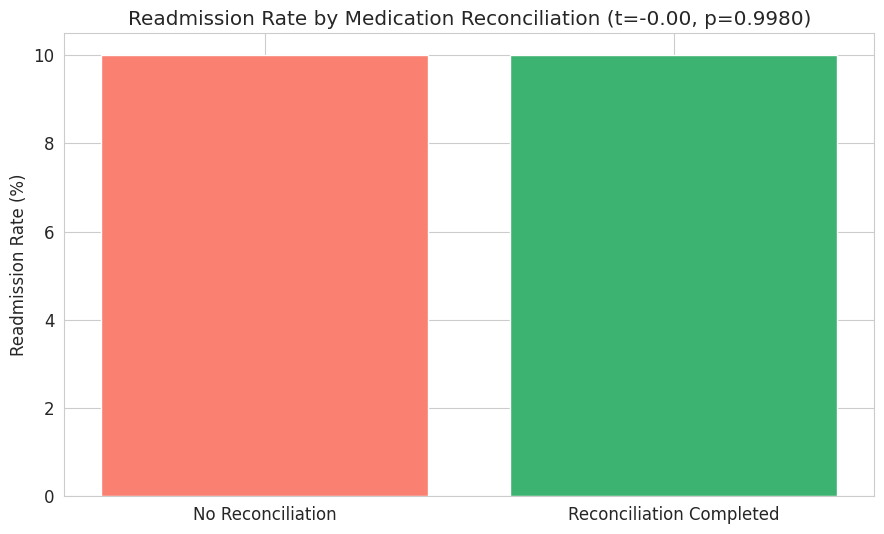

In [ ]:
# ======================================================================
# Q3A — T-TEST: READMISSION BY MEDICATION RECONCILIATION STATUS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Making medication reconciliation mandatory at discharge has a real
#   operational cost -- additional pharmacist or nurse time on every
#   single discharge. Before recommending that policy change to the
#   hospital board, Kenji needs rigorous statistical evidence, not just
#   the patient-level correlation from Question 2A, that completing
#   reconciliation is associated with a meaningfully lower readmission
#   rate.
# ======================================================================

# ── Step 1: Split patients by medication reconciliation status ──
recon_yes = patients_df[patients_df['MedRecon_Flag'] == 1]['Readmit_Flag']
recon_no = patients_df[patients_df['MedRecon_Flag'] == 0]['Readmit_Flag']

print(f"Reconciliation completed:     n = {len(recon_yes)}, readmission rate = {recon_yes.mean()*100:.1f}%")
print(f"Reconciliation NOT completed: n = {len(recon_no)}, readmission rate = {recon_no.mean()*100:.1f}%")

# ── Step 2: Run the independent-samples t-test ──
t_stat, p_val = stats.ttest_ind(recon_no, recon_yes)
print(f"\nt-statistic: {t_stat:.2f}")
print(f"p-value: {p_val:.6f}")

# ── Step 3: Compute Cohen's d ──
def cohens_d_healthcare(g1, g2):
    # Cohen d effect size: mean difference divided by the pooled standard deviation
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1 - 1) * g1.std()**2 + (n2 - 1) * g2.std()**2) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / pooled

d = cohens_d_healthcare(recon_no, recon_yes)
print(f"Cohen's d: {d:.2f}")

# ── Step 4: Bar chart comparing readmission rate by reconciliation status ──
plt.figure(figsize=(9, 5.5))
plt.bar(['No Reconciliation', 'Reconciliation Completed'],
        [recon_no.mean() * 100, recon_yes.mean() * 100],
        color=['salmon', 'mediumseagreen'])
plt.title(f'Readmission Rate by Medication Reconciliation (t={t_stat:.2f}, p={p_val:.4f})')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('medrecon_ttest_comparison.png', dpi=150)            # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> What do the t-statistic, p-value, and Cohen's d together tell you about this effect?
>
> What specific, mandatory policy recommendation follows from this result?



---

### Question 3B: ANOVA for Department Readmission Differences

**Prompt:** Dr. Sharma wants to know if readmission rates differ significantly across the four departments. What test should Kenji use? State the hypotheses.

**What to do:**
1. State H₀ (all department means equal) and H₁ (at least one differs).
2. Conduct a one-way ANOVA using `scipy.stats.f_oneway`.
3. Calculate eta-squared (η²) as an effect size.
4. Create a box plot by department.

**Deliverables:** Formal hypotheses; department group statistics; ANOVA F-statistic, p-value, and eta-squared; box plot saved as a `.png`; written interpretation.

**Purpose of this cell**

A one-way ANOVA is the appropriate test here for the same reason it was appropriate in the business case: we're comparing a numeric outcome (the readmission flag) across four independent groups (departments) simultaneously, rather than running multiple separate pairwise t-tests. We also compute eta-squared, an effect-size measure for ANOVA (analogous to Cohen's d for a t-test), which tells us what proportion of the total variance in readmission is explained by department membership alone.

Departments: ['General_Medicine' 'Cardiology' 'Orthopedics' 'Pulmonology']
  General_Medicine: n = 4416, mean = 0.0938, std = 0.2915
  Cardiology: n = 3028, mean = 0.1301, std = 0.3365
  Orthopedics: n = 2529, mean = 0.0652, std = 0.2470
  Pulmonology: n = 2427, mean = 0.1096, std = 0.3125

ANOVA F-statistic: 23.09
ANOVA p-value: 0.000000
Eta-squared (η²): 0.0056


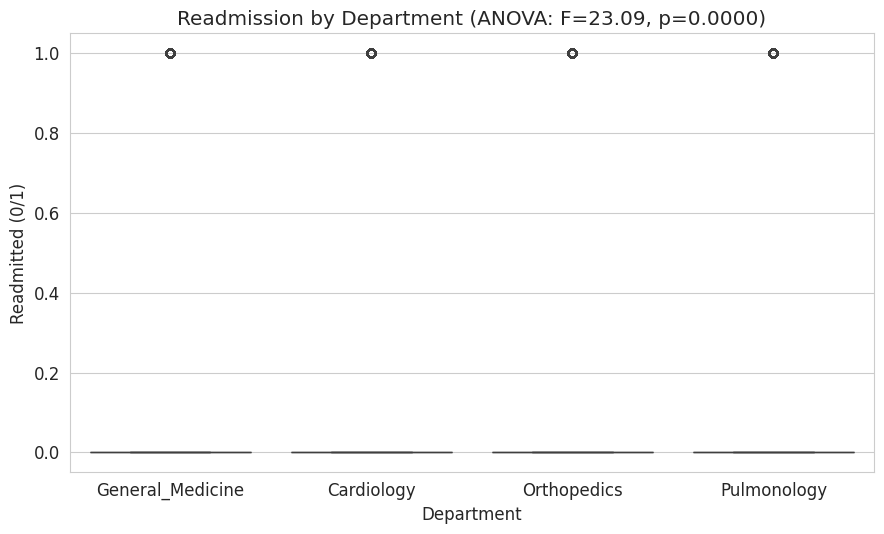

In [ ]:
# ======================================================================
# Q3B — ONE-WAY ANOVA: READMISSION RATES ACROSS FOUR DEPARTMENTS
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Before Dr. Sharma allocates scarce intervention budget differently
#   across Cardiology, Pulmonology, General Medicine, and Orthopedics,
#   she needs statistical confirmation that the department differences
#   we saw in Question 1A are real and not just random noise in a
#   12,400-patient dataset. The ANOVA provides exactly that
#   confirmation -- a single, rigorous test of whether department
#   matters at all for readmission risk.
# ======================================================================

# ── Step 1: State the hypotheses (conceptual, written as comments) ──
# H0: mu_Cardiology = mu_Pulmonology = mu_GeneralMedicine = mu_Orthopedics
#     (no difference in mean readmission rate across departments)
# H1: At least one department's mean readmission rate differs from the others

# ── Step 2: Confirm department categories and build one group per department ──
departments = patients_df['Department'].unique()
print(f"Departments: {departments}")

groups = [patients_df[patients_df['Department'] == d]['Readmit_Flag'] for d in departments]

# ── Step 3: Print group-level descriptive statistics before running the test ──
for d, g in zip(departments, groups):
    print(f"  {d}: n = {len(g)}, mean = {g.mean():.4f}, std = {g.std():.4f}")

# ── Step 4: Run the one-way ANOVA ──
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nANOVA F-statistic: {f_stat:.2f}")
print(f"ANOVA p-value: {p_val:.6f}")

# ── Step 5: Compute eta-squared (effect size for ANOVA) ──
# eta-squared = between-group sum of squares / total sum of squares
grand_mean = patients_df['Readmit_Flag'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = sum((patients_df['Readmit_Flag'] - grand_mean) ** 2)
eta_squared = ss_between / ss_total
print(f"Eta-squared (η²): {eta_squared:.4f}")
# Rule of thumb: 0.01 = small effect, 0.06 = medium, 0.14+ = large effect

# ── Step 6: Box plot of readmission flag by department ──
plt.figure(figsize=(9, 5.5))
sns.boxplot(x='Department', y='Readmit_Flag', data=patients_df)
plt.title(f'Readmission by Department (ANOVA: F={f_stat:.2f}, p={p_val:.4f})')
plt.ylabel('Readmitted (0/1)')
plt.tight_layout()
plt.savefig('dept_anova_boxplot.png', dpi=150)                  # REQUIRED filename per assignment instructions
plt.show()


### 📝 Your Answer

> What do the F-statistic and p-value tell you about department readmission rates?
>
> What does your eta-squared value tell you about the practical size of the department effect?



### Question 3C: Post-Hoc Test (Tukey's HSD)

**Prerequisite:** Your ANOVA must be significant before running this post-hoc test. If your Question 3B ANOVA was not significant, there is no statistical justification for proceeding with Tukey's HSD.

**What to do:**
1. Run Tukey HSD using `pairwise_tukeyhsd` from `statsmodels`.
2. Identify which of the six department pairs are statistically significant.
3. Create a p-value heatmap visualizing which departments differ.
4. Build a ranked department table comparing each department's rate to the 15.2% benchmark.

**Deliverables:** Full Tukey HSD table; filtered list of significant pairs; p-value heatmap saved as a `.png`; ranked department table; written resource allocation recommendation.

**Purpose of this cell**

A significant ANOVA only tells us that *some* department differs from *some* other department — it does not tell us which specific pairs. Tukey's HSD (Honestly Significant Difference) test makes all six possible pairwise department comparisons at once, while controlling the family-wise error rate (the increased risk of a false positive that comes from running many tests). This is the test that turns 'departments differ somewhere' into a specific, actionable map of which departments need attention and which can serve as an internal benchmark.

We also build a p-value heatmap, since a table of six pairwise rows can be harder to scan quickly than a color-coded grid where red cells immediately draw the eye to the significant differences.

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
      Cardiology General_Medicine  -0.0364    0.0 -0.0545 -0.0182   True
      Cardiology      Orthopedics  -0.0649    0.0 -0.0856 -0.0442   True
      Cardiology      Pulmonology  -0.0205 0.0572 -0.0415  0.0004  False
General_Medicine      Orthopedics  -0.0285 0.0008 -0.0477 -0.0093   True
General_Medicine      Pulmonology   0.0159  0.154 -0.0036  0.0353  False
     Orthopedics      Pulmonology   0.0444    0.0  0.0225  0.0662   True
------------------------------------------------------------------------

Significant pairs: 4 out of 6 total comparisons
             group1            group2  meandiff  p-adj
0        Cardiology  General_Medicine   -0.0364 0.0000
1        Cardiology       Orthopedics   -0.0649 0.0000
3  General_Medicine       Orthopedics   -0.0285 0.0008
5

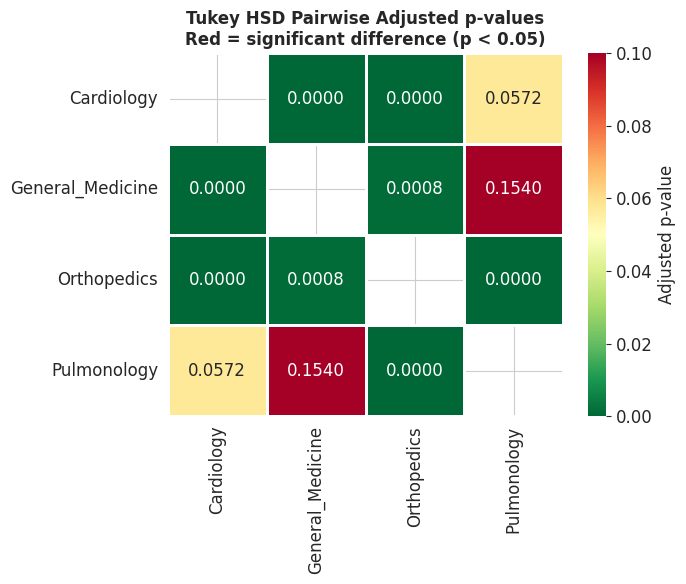


=== Department Readmission Rates (Ranked) ===
  Cardiology             13.0%   vs. 15.2% benchmark: BELOW
  Pulmonology            11.0%   vs. 15.2% benchmark: BELOW
  General_Medicine        9.4%   vs. 15.2% benchmark: BELOW
  Orthopedics             6.5%   vs. 15.2% benchmark: BELOW


In [ ]:
# ======================================================================
# Q3C — TUKEY HSD POST-HOC TEST: WHICH DEPARTMENT PAIRS DIFFER
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   This is the single most actionable output in the entire healthcare
#   case study. It converts the general finding 'departments differ' into
#   a specific, defensible map: exactly which department(s) should
#   receive urgent intervention resources first, which can serve as an
#   internal best-practice benchmark, and which pairs are statistically
#   indistinguishable from each other and therefore don't need to be
#   treated as fundamentally different problems.
# ======================================================================

# ── Step 1: Confirm the prerequisite -- only proceed if Q3B's ANOVA was significant ──
if p_val >= 0.05:
    print("WARNING: The ANOVA from Question 3B was not significant.")
    print("There is no statistical justification for running Tukey's HSD. Stopping here.")
else:
    # ── Step 2: Run Tukey's HSD across all department pairs ──
    tukey = pairwise_tukeyhsd(patients_df['Readmit_Flag'], patients_df['Department'], alpha=0.05)
    print(tukey)

    # ── Step 3: Convert the Tukey results into a DataFrame for easier filtering ──
    tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                             columns=tukey._results_table.data[0])

    # ── Step 4: Filter down to ONLY the statistically significant pairs ──
    sig_pairs = tukey_df[tukey_df['reject'] == True]
    print(f"\nSignificant pairs: {len(sig_pairs)} out of {len(tukey_df)} total comparisons")
    print(sig_pairs[['group1', 'group2', 'meandiff', 'p-adj']])

    # ── Step 5: Build a symmetric p-value matrix for the heatmap ──
    depts_sorted = sorted(patients_df['Department'].unique())
    n = len(depts_sorted)
    p_matrix = pd.DataFrame(np.ones((n, n)), index=depts_sorted, columns=depts_sorted)

    for _, row in tukey_df.iterrows():
        g1, g2 = row['group1'], row['group2']
        pv = float(row['p-adj'])
        p_matrix.loc[g1, g2] = pv
        p_matrix.loc[g2, g1] = pv                                    # Matrix is symmetric

    for d in depts_sorted:
        p_matrix.loc[d, d] = np.nan                                    # A department vs. itself is meaningless

    # ── Step 6: Plot the p-value heatmap ──
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(p_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r',
                vmin=0, vmax=0.10, ax=ax, linewidths=2, linecolor='white',
                cbar_kws={'label': 'Adjusted p-value'})
    ax.set_title('Tukey HSD Pairwise Adjusted p-values\nRed = significant difference (p < 0.05)',
                  fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tukey_hsd_heatmap.png', dpi=150, bbox_inches='tight')   # REQUIRED filename per assignment instructions
    plt.show()

    # ── Step 7: Ranked department table for context alongside the significance tests ──
    print("\n=== Department Readmission Rates (Ranked) ===")
    dept_rates_ranked = patients_df.groupby('Department')['Readmit_Flag'].mean().sort_values(ascending=False)
    for dept, rate in dept_rates_ranked.items():
        status = 'ABOVE' if rate > 0.152 else 'BELOW'
        print(f"  {dept:<20} {rate*100:>6.1f}%   vs. 15.2% benchmark: {status}")


### 📝 Your Answer

> Why was Tukey's HSD test necessary after the ANOVA, instead of just looking at the ANOVA result alone?
>
> What does “family-wise error rate” mean, and why does it matter when making six comparisons at once?
>
> Of the six pairwise comparisons, how many were statistically significant? Which two departments showed the largest gap, and what was the adjusted p-value?
>
> Which two departments were NOT significantly different from each other, and what might that suggest?
>
> Based on all of this, which department requires the most urgent intervention? Propose two specific interventions for that department, and rank the remaining departments by priority.



---

## Question 4: Strategic Recommendations (25 points)

**Prompt:** Develop a data-driven intervention plan with at least three prioritized recommendations to reduce readmissions below the 15.2% national benchmark.

This question is answered primarily in writing (as a separate typed document, per the assignment instructions: *"Upload your responses as a typed document. Label your file as Question 4 (Your Name)."*). The code cell below helps you organize your evidence; the heart of Question 4 is the written analysis described below.

**Part A:** Develop a data-driven intervention plan with at least three prioritized recommendations. Address:
- What were the F-statistic and p-value from your one-way ANOVA (Q3B)? What does this tell you about department readmission rates?
- Why can't the ANOVA result alone identify which specific departments differ?
- What is the purpose of Tukey's HSD after a significant ANOVA, and what does "family-wise error rate" mean?
- Of the six pairwise comparisons, how many pairs were significant? Which two departments showed the largest gap (with the mean difference and adjusted p-value)? Which two were not significantly different, and what might that suggest?
- Which department requires the most urgent intervention? Propose two specific interventions for it. Rank the remaining departments by priority. For departments at or below benchmark, what monitoring approach would you recommend?

**Part B:** For each recommendation, quantify the expected impact using the data (e.g., the follow-up completion scenario from Question 2C/2D). Address:
- What are the current baseline numbers, and what does the gap to your target represent in real patient outcomes?
- If follow-up completion rises to your target rate, how many fewer readmissions does that translate to, and what assumptions are you making?
- Would the impact be evenly distributed across patient populations?
- How are you accounting for uncertainty rather than presenting projections as guarantees?
- What is your realistic time horizon for seeing results?

**Part C:** How should Kenji present these findings to the hospital board (clinical leaders and financial officers)? Address:
- What does the clinical side need to see versus the financial side, and where do priorities overlap?
- How can you translate clinical metrics into financial terms (and vice versa)?
- When is a simple chart more effective than a detailed dashboard for this audience?
- How should Kenji handle findings where clinical needs and financial concerns are in tension?
- What narrative connects the visualizations so the board leaves with a unified understanding?

**Deliverables:** A separate typed document (not this notebook) containing your written intervention plan, organized as Parts A, B, and C above.

**Purpose of this cell**

As with the business case, this is optional scaffolding to help organize your evidence before writing the Question 4 document — it is not itself the graded deliverable.

In [ ]:
# ======================================================================
# Q4 — OPTIONAL SCAFFOLDING: ORGANIZING YOUR INTERVENTION PLAN
# ======================================================================
#
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A hospital board with both clinical and financial leaders needs
#   recommendations that are concrete, prioritized, and tied to a
#   specific number from the analysis -- not a vague call to 'improve
#   readmissions.' Building this table forces you to connect every
#   recommendation in your written plan back to a specific statistic
#   you actually computed in Questions 1 through 3.
# ======================================================================

# ── This is a TEMPLATE you should fill in with YOUR OWN findings from Q1-Q3 ──

intervention_plan = pd.DataFrame({
    'Priority': [1, 2, 3],
    'Recommendation': [
        '[YOUR RECOMMENDATION 1 -- replace this text]',
        '[YOUR RECOMMENDATION 2 -- replace this text]',
        '[YOUR RECOMMENDATION 3 -- replace this text]',
    ],
    'Data_Evidence': [
        '[Cite a specific statistic from your Q1-Q3 analysis]',
        '[Cite a specific statistic from your Q1-Q3 analysis]',
        '[Cite a specific statistic from your Q1-Q3 analysis]',
    ],
    'Projected_Impact': [
        '[Quantified projected impact, e.g. estimated readmission reduction]',
        '[Quantified projected impact, e.g. estimated readmission reduction]',
        '[Quantified projected impact, e.g. estimated readmission reduction]',
    ]
})

print(intervention_plan.to_string(index=False))
intervention_plan.to_csv('q4_intervention_plan_draft.csv', index=False)


 Priority                               Recommendation                                        Data_Evidence                                                    Projected_Impact
        1 [YOUR RECOMMENDATION 1 -- replace this text] [Cite a specific statistic from your Q1-Q3 analysis] [Quantified projected impact, e.g. estimated readmission reduction]
        2 [YOUR RECOMMENDATION 2 -- replace this text] [Cite a specific statistic from your Q1-Q3 analysis] [Quantified projected impact, e.g. estimated readmission reduction]
        3 [YOUR RECOMMENDATION 3 -- replace this text] [Cite a specific statistic from your Q1-Q3 analysis] [Quantified projected impact, e.g. estimated readmission reduction]


### 📝 Your Answer

> This is a reminder, not a question: Question 4 must be submitted as a SEPARATE TYPED DOCUMENT, labeled 'Question 4 (Your Name)', not as a cell in this notebook.
>
> Use the table above as a working draft, but write your full Part A / Part B / Part C response in that separate document, addressing every bullet point listed in the prompt above.
>

(No response needed in this cell — this is a reminder about the separate Question 4 submission.)


---

# Case Study 3: Public Administration

## "Closing the Equity Gap at Riverside County Department of Social Services"

**Background:** Riverside County (population 1.2 million) faces growing scrutiny over disparities in the delivery of social services. A state audit found that application processing times for SNAP, TANF, and Medicaid varied dramatically across eight district offices — some residents wait three times longer than others. Community advocacy groups allege the disparities correlate with the racial and socioeconomic composition of the districts served.

County Administrator **Diane Torres** has appointed Policy Analyst **Marcus Rivera** to conduct a rigorous data analysis and present findings to the County Board of Supervisors within six weeks.

**Preliminary Findings (from case background):**
- Processing time: **11 days** (District 3, lowest poverty) to **34 days** (District 7, highest poverty)
- Poverty rate vs. processing time: **r = 0.82**
- Minority population vs. processing time: **r = 0.76**
- Digital districts: **14 days** avg vs. **29 days** for non-digital
- Multiple regression R² = 0.88 | Caseworker Ratio (b=−4.20, p=0.006), Poverty Rate (b=0.58, p=0.011), Digital Access (b=−9.30, p=0.003)
- Satisfaction t-test: **t = 5.12, p < 0.0001** (digital mean=74, non-digital mean=52)
- ANOVA across districts: **F = 12.47, p < 0.0001**

**Datasets:**

| File | Contents | Records |
|---|---|---|
| Application Records | App type, submission/completion dates, processing days, approval status, district | 34,000 applications |
| District Demographics | Median income, poverty rate, minority %, English-limited %, population density | 8 districts |
| Staffing & Operations | Caseworkers per 1,000 apps, caseload, office hours, digital access (yes/no) | 8 districts |
| Client Survey | Satisfaction score (1–100), ease of access, language barrier, digital literacy | 2,800 responses |

**Public Administration majors: complete this entire section. All others skip to your own section.**


## Setup and Data Loading

**Purpose of this cell**

We load all four Public Administration datasets and inspect their structure before any analysis. Because the datasets operate at different levels of aggregation — 34,000 individual applications, 8-row district summaries, and 2,800 survey responses — confirming column names and shapes now prevents silent errors in every step that follows.

Adapt the filenames and column names below to match your actual uploaded files.

In [ ]:
# ======================================================================
# LOAD AND INSPECT ALL PUBLIC ADMINISTRATION DATASETS
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Marcus has six weeks to deliver findings to the County Board.
#   Before any equity analysis can begin, he must confirm exactly
#   what data he has: which districts are represented, which app
#   types are included, and whether the files can be linked at
#   the district level. This cell is that foundational check.
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Load all four datasets ── replace filenames with your actual uploaded file names
apps_df   = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/applications.csv')          # 34,000 individual application records
demos_df  = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/district_demographics.csv') # 8 district demographic rows
ops_df    = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/district_operations.csv')   # 8 district operations/staffing rows
survey_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/client_survey.csv')          # 2,800 client survey responses

# ── Confirm shape (rows, columns) of each dataset ──
print("applications.csv       :", apps_df.shape)
print("district_demographics  :", demos_df.shape)
print("district_operations    :", ops_df.shape)
print("client_survey.csv      :", survey_df.shape)

# ── Print column names so every later cell can reference them correctly ──
print("\nApplications columns :", list(apps_df.columns))
print("Demographics columns  :", list(demos_df.columns))
print("Operations columns    :", list(ops_df.columns))
print("Survey columns        :", list(survey_df.columns))

apps_df.head()


applications.csv       : (34000, 8)
district_demographics  : (8, 7)
district_operations    : (8, 6)
client_survey.csv      : (2800, 7)

Applications columns : ['application_id', 'district', 'application_type', 'submission_date', 'completion_date', 'processing_days', 'approval_status', 'digital_access']
Demographics columns  : ['district', 'digital_access', 'median_income_usd', 'poverty_rate', 'minority_population_pct', 'english_limited_pct', 'population_density']
Operations columns    : ['district', 'digital_access', 'caseworkers_per_1000_apps', 'avg_caseload', 'office_hours_per_week', 'num_office_locations']
Survey columns        : ['response_id', 'district', 'digital_access', 'satisfaction_score', 'ease_of_access_rating', 'language_barrier', 'digital_literacy_rating']


,application_id,district,application_type,submission_date,completion_date,processing_days,approval_status,digital_access
0,APP000001,District_1,SNAP,2024-12-23,2025-01-07,15,1,1
1,APP000002,District_1,Medicaid,2023-10-12,2023-10-19,7,1,1
2,APP000003,District_1,SNAP,2024-04-25,2024-05-12,17,1,1
3,APP000004,District_1,SNAP,2023-04-28,2023-05-16,18,1,1
4,APP000005,District_1,SNAP,2024-06-15,2024-06-17,2,0,1


**Purpose of this cell**

The regression model and district-level analyses need a single merged district-level DataFrame that combines operational data (caseworker ratios, digital access) with demographic data (poverty rate, minority %) and computed processing-time averages. This cell builds that merged table.

In [ ]:
# ======================================================================
# BUILD THE DISTRICT-LEVEL MERGED DATAFRAME
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   The regression predicts processing days at the DISTRICT level
#   (8 rows), not the application level (34,000 rows). Merging all
#   district data sources into one clean table gives Marcus the right
#   granularity for every downstream analysis.
# ======================================================================

# ── Step 1: Compute per-district mean processing days from applications file ──
district_apps = apps_df.groupby('district').agg(
    processing_days=('processing_days', 'mean'),  # mean processing days per district
    total_apps=('processing_days', 'count')        # total applications per district
).reset_index()

print("District-level processing day averages:")
print(district_apps.round(2))

# ── Step 2: Compute per-district mean satisfaction from survey file ──
district_sat = survey_df.groupby('district')['satisfaction_score'].mean().reset_index()
district_sat.columns = ['district', 'satisfaction_score']

# ── Step 3: Merge demographics + operations + processing + satisfaction ──
# ops_df has digital_access too -- drop it before merging to avoid duplicate columns
ops_clean = ops_df.drop(columns=['digital_access'], errors='ignore')

df = demos_df.merge(ops_clean,       on='district')  # demographics + operations (no dup cols)
df = df.merge(district_apps,         on='district')  # add per-district processing averages
df = df.merge(district_sat,          on='district')  # add per-district satisfaction scores

print("\nMerged district DataFrame shape:", df.shape)
print("Columns:", list(df.columns))
print(df.round(2))


District-level processing day averages:
     district  processing_days  total_apps
0  District_1          12.9300        4800
1  District_2          27.4200        4200
2  District_3          10.9900        3900
3  District_4          30.8300        4600
4  District_5          18.0500        4100
5  District_6          25.9500        4400
6  District_7          33.7900        4500
7  District_8          24.0700        3500

Merged district DataFrame shape: (8, 14)
Columns: ['district', 'digital_access', 'median_income_usd', 'poverty_rate', 'minority_population_pct', 'english_limited_pct', 'population_density', 'caseworkers_per_1000_apps', 'avg_caseload', 'office_hours_per_week', 'num_office_locations', 'processing_days', 'total_apps', 'satisfaction_score']
     district  digital_access  median_income_usd  poverty_rate  \
0  District_1               1              72000        9.8000   
1  District_2               0              49000       18.5000   
2  District_3               1      

---

## Question 1: Descriptive and Exploratory Analysis (25 points)

### Question 1A: Processing Time Disparities Across Eight Districts

**Prompt:** Analyze the processing time disparities across the eight districts. What do the descriptive statistics (range from 11 to 34 days) reveal about equity in service delivery?

**What to do:** Compute processing time statistics by district (mean, median, std, min, max); calculate range, ratio, and coefficient of variation; create a horizontal bar chart with county-average reference line.

**Deliverables:** District summary table; chart saved as `q1a_district_disparity.png`; written interpretation.

**Purpose of this cell**

This code quantifies the core equity gap: how large is the spread across districts, and how do we express that spread in a way that is meaningful to a county board? We compute the range, the fastest-to-slowest ratio, and the coefficient of variation — three complementary measures that together tell a richer story than any single number alone.

District Processing Time Summary:
     district  processing_days  poverty_rate  digital_access
6  District_7          33.7900       35.6000               0
3  District_4          30.8300       28.3000               0
1  District_2          27.4200       18.5000               0
5  District_6          25.9500       22.7000               0
7  District_8          24.0700       17.9000               0
4  District_5          18.0500       21.4000               1
0  District_1          12.9300        9.8000               1
2  District_3          10.9900        7.2000               1

Fastest district average: 11.0 days
Slowest district average:  33.8 days
Range:                     22.8 days
Ratio:                     3.1x slower
Coefficient of Variation:  35.89%


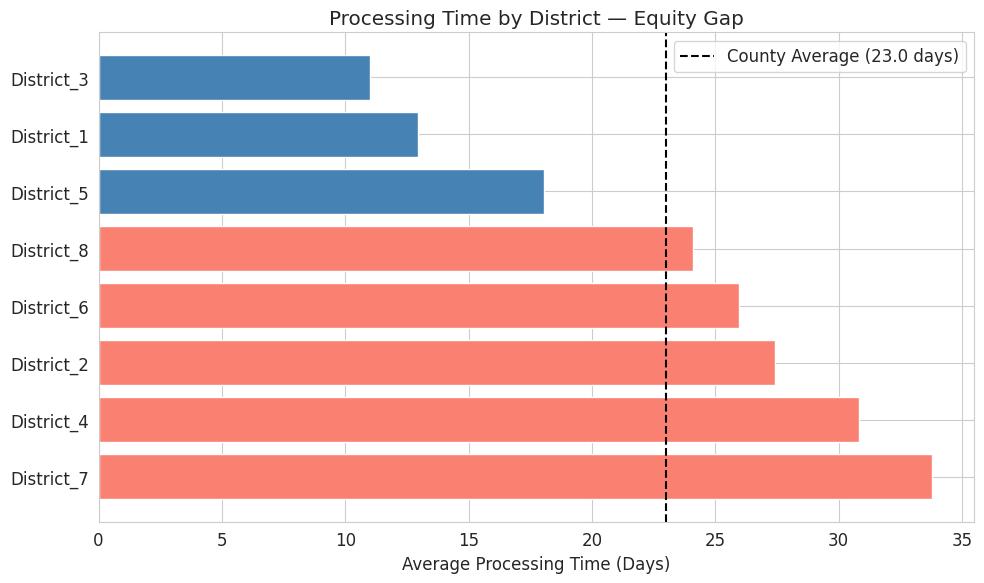

In [ ]:
# ======================================================================
# Q1A — PROCESSING TIME DISPARITIES ACROSS ALL EIGHT DISTRICTS
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Before Marcus can propose any fix, the County Board needs a
#   clear quantified picture of exactly how unequal processing
#   times are. A 3x gap between the fastest and slowest district
#   is a fundamentally different policy problem than a 10% gap.
# ======================================================================

# ── Step 1: Sort districts from slowest to fastest ──
district_summary = df.sort_values('processing_days', ascending=False)

print("District Processing Time Summary:")
print(district_summary[['district','processing_days','poverty_rate','digital_access']].round(2))

# ── Step 2: Three key disparity metrics ──
fastest  = df['processing_days'].min()    # fastest district mean
slowest  = df['processing_days'].max()    # slowest district mean
county_avg = df['processing_days'].mean() # county-wide average

print(f"\nFastest district average: {fastest:.1f} days")
print(f"Slowest district average:  {slowest:.1f} days")
print(f"Range:                     {slowest - fastest:.1f} days")
print(f"Ratio:                     {slowest / fastest:.1f}x slower")

# Coefficient of Variation = std / mean (measures relative inequality)
cv = df['processing_days'].std() / df['processing_days'].mean()
print(f"Coefficient of Variation:  {cv:.2%}")

# ── Step 3: Horizontal bar chart with county-average reference line ──
plt.figure(figsize=(10, 6))
colors = ['salmon' if x > 20 else 'steelblue' for x in district_summary['processing_days']]
plt.barh(district_summary['district'], district_summary['processing_days'], color=colors)
plt.axvline(x=county_avg, color='black', linestyle='--',
            label=f'County Average ({county_avg:.1f} days)')
plt.xlabel('Average Processing Time (Days)')
plt.title('Processing Time by District — Equity Gap')
plt.legend()
plt.tight_layout()
plt.savefig('q1a_district_disparity.png', dpi=150)   # Required filename
plt.show()


### 📝 Your Answer

> What does the range (and ratio) between the fastest and slowest districts reveal about equity in service delivery?
>
> Which districts are most concerning, and what might account for their processing times?



### Question 1B: Evaluating Claims of Racial Bias

**Prompt:** The advocacy groups allege racial bias. Using the correlations provided (poverty rate r = 0.82, minority population r = 0.76), evaluate whether the data supports these claims. What are the limitations of using correlation to establish discriminatory intent?

**What to do:** Compute and verify both correlations; create scatter plots with regression lines; check the poverty-minority confound.

**Deliverables:** Correlation values and p-values; scatter plots saved as `q1b_bias_correlations.png`; written interpretation including stated limitations.

**Purpose of this cell**

This code verifies the two headline correlations from the case background and, critically, also checks whether poverty rate and minority population percentage are correlated with each other at the district level. If those two variables move together (which is common due to historical patterns of segregation and disinvestment), it becomes statistically impossible to separate their effects using correlation alone — both variables would show a pattern with processing time even if only one were driving it.

Note: with only 8 district observations, all p-values should be interpreted with caution given the very small sample size.

Poverty rate vs. processing time:    r = 0.90, p = 0.0021
Minority pop vs. processing time:    r = 0.92, p = 0.0013


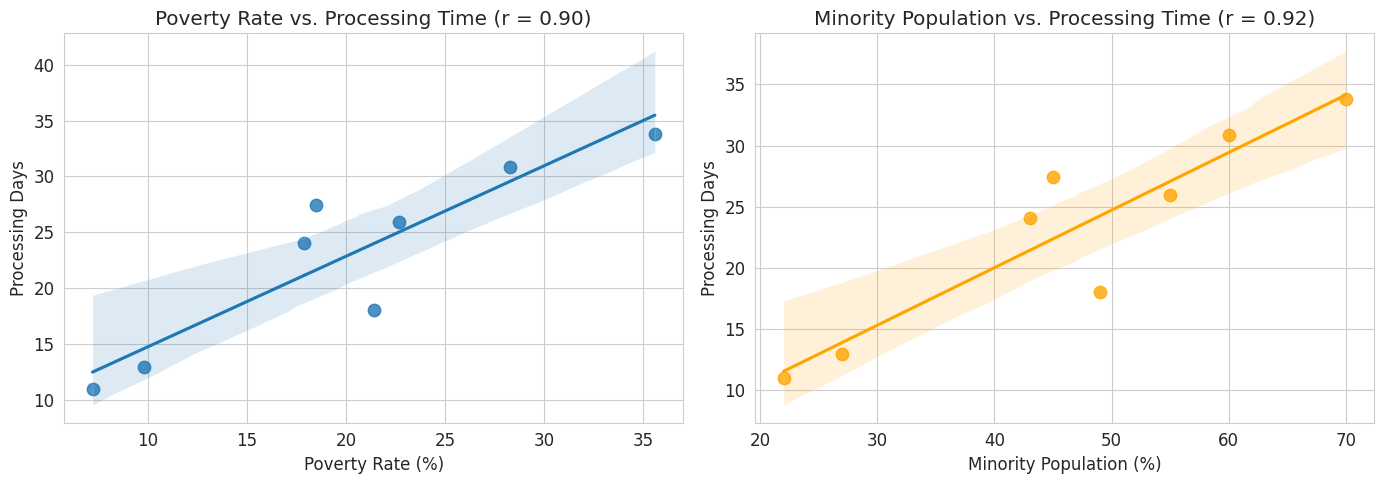


Confound check — Poverty vs. minority population: r = 0.99, p = 0.0000
If r is large here, the two variables move together and cannot be treated as independent.


In [ ]:
# ======================================================================
# Q1B — CORRELATIONS: POVERTY, MINORITY POPULATION, AND PROCESSING TIME
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A public administrator who overstates what correlation proves
#   risks legal exposure and political backlash. Getting the
#   statistical nuance right -- correlation is evidence of a
#   pattern, not proof of intent -- is the core skill this tests.
# ======================================================================

# ── Step 1: Compute and verify the two headline correlations ──
r_poverty,  p_poverty  = stats.pearsonr(df['poverty_rate'],           df['processing_days'])
r_minority, p_minority = stats.pearsonr(df['minority_population_pct'],df['processing_days'])

print(f"Poverty rate vs. processing time:    r = {r_poverty:.2f}, p = {p_poverty:.4f}")
print(f"Minority pop vs. processing time:    r = {r_minority:.2f}, p = {p_minority:.4f}")

# ── Step 2: Scatter plots with regression lines ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x='poverty_rate', y='processing_days', data=df, ax=axes[0],
            scatter_kws={'s': 80, 'alpha': 0.8})
axes[0].set_title(f'Poverty Rate vs. Processing Time (r = {r_poverty:.2f})')
axes[0].set_xlabel('Poverty Rate (%)')
axes[0].set_ylabel('Processing Days')

sns.regplot(x='minority_population_pct', y='processing_days', data=df, ax=axes[1],
            scatter_kws={'s': 80, 'alpha': 0.8}, color='orange')
axes[1].set_title(f'Minority Population vs. Processing Time (r = {r_minority:.2f})')
axes[1].set_xlabel('Minority Population (%)')
axes[1].set_ylabel('Processing Days')

plt.tight_layout()
plt.savefig('q1b_bias_correlations.png', dpi=150)    # Required filename
plt.show()

# ── Step 3: Confound check — are poverty and minority % correlated with each other? ──
# If yes, their effects on processing time cannot be separated by correlation alone
r_pov_min, p_pov_min = stats.pearsonr(df['poverty_rate'], df['minority_population_pct'])
print(f"\nConfound check — Poverty vs. minority population: r = {r_pov_min:.2f}, p = {p_pov_min:.4f}")
print("If r is large here, the two variables move together and cannot be treated as independent.")


### 📝 Your Answer

> Do the correlations (r=0.82 and r=0.76) support, contradict, or remain ambiguous about the advocacy groups' bias claims?
>
> What does your confound check reveal, and how does it complicate interpretation of either correlation on its own?
>
> State at least two specific limitations of using correlation to establish discriminatory intent.



### Question 1C: Digital vs. Non-Digital District Profiles

**Prompt:** Compare digital versus non-digital districts across all available metrics. What profile emerges, and what does it suggest about the digital divide in public services?

**What to do:** Split districts by digital access; compare all metrics; create side-by-side bar charts.

**Deliverables:** Profile table; bar charts saved as `q1c_digital_divide.png`; written interpretation.

**Purpose of this cell**

This code profiles digital and non-digital districts across every available metric at once to determine whether digital access is an isolated operational difference, or whether it is bundled together with other systemic disadvantages (lower staffing, higher poverty, lower satisfaction). That distinction matters enormously: if non-digital districts are also poorer, more understaffed, and serving higher-need populations, then deploying portals alone will not close the equity gap.

Digital districts: n=3 | Non-digital: n=5

Digital vs. Non-Digital District Profile:
                           Digital_Mean  Non_Digital_Mean  Difference  \
processing_days                 13.9900           28.4100    -14.4200   
satisfaction_score              74.4900           50.3600     24.1300   
poverty_rate                    12.8000           24.6000    -11.8000   
minority_population_pct         32.6700           54.6000    -21.9300   
caseworkers_per_1000_apps        4.5300            2.5200      2.0100   
english_limited_pct              9.5300           22.1000    -12.5700   
avg_caseload                   227.6700          415.0000   -187.3300   
office_hours_per_week           47.6700           38.0000      9.6700   

                           Pct_Difference  
processing_days                  -50.7600  
satisfaction_score                47.9100  
poverty_rate                     -47.9700  
minority_population_pct          -40.1700  
caseworkers_per_1000_apps         79.

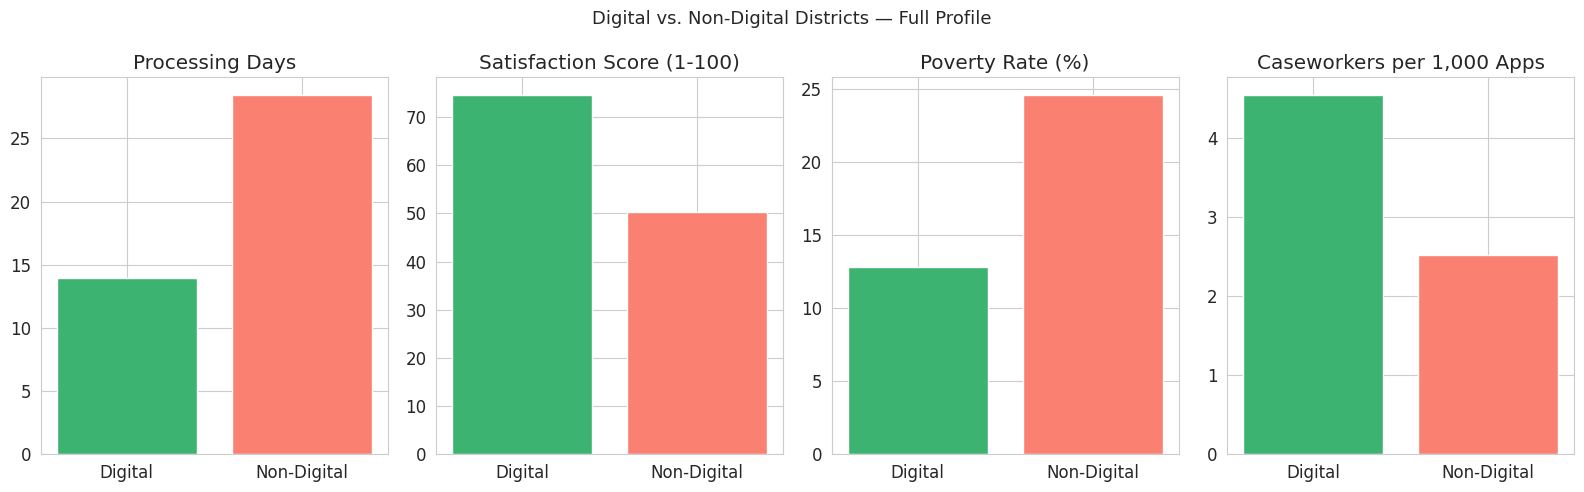

In [ ]:
# ======================================================================
# Q1C — DIGITAL VS. NON-DIGITAL DISTRICT PROFILE COMPARISON
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   The regression identified digital access as the biggest lever.
#   Before recommending a portal rollout as the primary fix, Marcus
#   should confirm that non-digital districts differ ONLY on digital
#   access -- not on many other dimensions that would make the
#   comparison misleading or the fix incomplete.
# ======================================================================

# ── Step 1: Split the district-level merged DataFrame by digital access ──
digital     = df[df['digital_access'] == 1]   # digital districts (have online portal)
non_digital = df[df['digital_access'] == 0]   # non-digital districts (paper-only)

print(f"Digital districts: n={len(digital)} | Non-digital: n={len(non_digital)}")

# ── Step 2: Build a comparison profile across all available metrics ──
# These column names come from the merged district-level df built in the setup cell
compare_vars = [
    'processing_days',           # mean processing time per district
    'satisfaction_score',        # mean citizen satisfaction per district
    'poverty_rate',              # district poverty rate %
    'minority_population_pct',   # district minority population %
    'caseworkers_per_1000_apps', # staffing intensity
    'english_limited_pct',       # share of English-limited households
    'avg_caseload',              # average caseworker caseload
    'office_hours_per_week',     # weekly office hours available
]

profile = pd.DataFrame()
for v in compare_vars:
    profile.loc[v, 'Digital_Mean']     = digital[v].mean()
    profile.loc[v, 'Non_Digital_Mean'] = non_digital[v].mean()
    profile.loc[v, 'Difference']       = digital[v].mean() - non_digital[v].mean()
    profile.loc[v, 'Pct_Difference']   = ((digital[v].mean() - non_digital[v].mean())
                                           / non_digital[v].mean() * 100)

print("\nDigital vs. Non-Digital District Profile:")
print(profile.round(2))

# ── Step 3: Side-by-side bar charts for the four most decision-relevant metrics ──
key_vars   = ['processing_days', 'satisfaction_score',
              'poverty_rate',    'caseworkers_per_1000_apps']
key_labels = ['Processing Days',    'Satisfaction Score (1-100)',
              'Poverty Rate (%)',    'Caseworkers per 1,000 Apps']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, (v, lbl) in enumerate(zip(key_vars, key_labels)):
    axes[i].bar(['Digital', 'Non-Digital'],
                [digital[v].mean(), non_digital[v].mean()],
                color=['mediumseagreen', 'salmon'])
    axes[i].set_title(lbl)

plt.suptitle('Digital vs. Non-Digital Districts — Full Profile', fontsize=13)
plt.tight_layout()
plt.savefig('q1c_digital_divide.png', dpi=150)    # Required filename
plt.show()


### 📝 Your Answer

> What profile emerges when comparing digital and non-digital districts across all metrics?
>
> Does the evidence suggest digital access is an isolated gap or bundled with other systemic disadvantages?
>
> What does this imply about the appropriate scope of the policy response?



---

## Question 2: Correlation and Regression Analysis (25 points)

### Question 2A: Interpreting the Multiple Regression (R² = 0.88)

**Prompt:** Interpret the multiple regression model (R² = 0.88). What does each coefficient mean in practical terms for county operations?

**What to do:** Fit a multiple regression predicting processing days from caseworker ratio, poverty rate, digital access, and minority population %; print the full summary and write out the equation.

**Deliverables:** Full `model.summary()` output; written regression equation; coefficient interpretation table; written narrative.

**Purpose of this cell**

This code builds the central regression model for the Public Administration case, predicting average processing days from staffing levels, poverty rate, digital access, and minority population percentage. The model's R² = 0.88 means 88% of the district-to-district variation in processing time is explained by these four variables together, which is unusually high for social science observational data and suggests the model captures most of the structural drivers.

Because there are only 8 districts, interpret individual coefficients cautiously. Note: minority_population_pct is included as a predictor as specified in the case background, but its coefficient must be interpreted carefully given the correlation-vs-causation discussion in Q1B.

In [ ]:
# ======================================================================
# Q2A — MULTIPLE REGRESSION: PREDICTING PROCESSING DAYS
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A regression model lets Marcus move from "districts differ" to
#   a specific, quantified explanation the Board can act on: which
#   levers, if pulled, would reduce processing time the most?
# ======================================================================

# ── Step 1: Build digital/non-digital subsets for use in Q2B predictions ──
digital_d     = df[df['digital_access'] == 1]
non_digital_d = df[df['digital_access'] == 0]

# ── Step 2: Define predictors (X) and outcome (y) ──
# All column names reference the merged district-level df from the setup cell
X_cols = ['caseworkers_per_1000_apps', 'poverty_rate', 'digital_access']
X = df[X_cols]
y = df['processing_days']

# ── Step 3: Add a constant (intercept) and fit the OLS regression ──
X_const = sm.add_constant(X)
model   = sm.OLS(y, X_const).fit()

# ── Step 4: Print the full statistical summary ──
print(model.summary())

# ── Step 5: Clean coefficient results table ──
results = pd.DataFrame({
    'Coefficient':        model.params.round(4),
    'Std_Error':          model.bse.round(4),
    't_value':            model.tvalues.round(2),
    'p_value':            model.pvalues.round(4),
    'Significant_at_0.05': model.pvalues < 0.05
})
print("\nCoefficient Summary:")
print(results)

# ── Step 6: Write out the fitted regression equation ──
coeffs   = model.params
equation = f"Processing Days = {coeffs['const']:.2f}"
for var in X_cols:
    sign     = '+' if coeffs[var] >= 0 else '-'
    equation += f" {sign} {abs(coeffs[var]):.2f} x {var}"
print("\nRegression Equation:")
print(equation)


                            OLS Regression Results                            
Dep. Variable:        processing_days   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     82.76
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           0.000469
Time:                        17:24:27   Log-Likelihood:                -11.129
No. Observations:                   8   AIC:                             30.26
Df Residuals:                       4   BIC:                             30.58
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### 📝 Your Answer

> Write out the regression equation using your actual fitted coefficients.
>
> Interpret each coefficient in plain policy language a county administrator would understand.
>
> What does R² = 0.88 mean for understanding what drives processing time variation across the county?



### Question 2B: Digital Access Coefficient (−9.30)

**Prompt:** Digital Access has the largest absolute coefficient (−9.30). Explain what this means: if a non-digital district adopted a digital portal, how many fewer processing days would the model predict, holding other variables constant?

**What to do:** Isolate the digital access coefficient and its 95% CI; predict processing days for an average non-digital district with and without a portal.

**Deliverables:** Coefficient, CI, and p-value; printed before/after prediction; written interpretation.

**Purpose of this cell**

This code demonstrates a concrete 'what-if' prediction: taking the average profile of a non-digital district and asking the fitted model what would happen if we changed only the digital access variable, holding every other variable at its current average value. This turns an abstract regression coefficient into a specific, defensible projection that the County Board can use to evaluate the cost vs. benefit of a portal expansion.

In [ ]:
# ======================================================================
# Q2B — PREDICTING THE IMPACT OF DIGITAL PORTAL ADOPTION
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Approving portal expansion is a real budget decision. Marcus
#   needs a specific, defensible prediction: "if District X adopts
#   a portal, processing time drops by approximately Y days."
# ======================================================================

# ── Step 1: Isolate the digital access coefficient and confidence interval ──
coef_digital = model.params['digital_access']
ci_digital   = model.conf_int().loc['digital_access']
p_digital    = model.pvalues['digital_access']

print(f"Digital access coefficient: {coef_digital:.2f} days")
print(f"95% Confidence Interval:    [{ci_digital[0]:.2f}, {ci_digital[1]:.2f}]")
print(f"P-value:                    {p_digital:.4f}")

# ── Step 2: Predict processing days for an average non-digital district WITHOUT a portal ──
sample_nondigital       = non_digital_d[X_cols].mean().to_frame().T
sample_nondigital_const = sm.add_constant(sample_nondigital, has_constant='add')
pred_without            = model.predict(sample_nondigital_const)[0]

# ── Step 3: Same district's predicted days IF it adopted a portal ──
# Change ONLY digital_access from 0 to 1; hold every other variable constant
sample_with_digital                   = sample_nondigital.copy()
sample_with_digital['digital_access'] = 1
sample_with_digital_const             = sm.add_constant(sample_with_digital, has_constant='add')
pred_with                             = model.predict(sample_with_digital_const)[0]

print(f"\nPredicted processing days WITHOUT portal: {pred_without:.1f}")
print(f"Predicted processing days WITH portal:    {pred_with:.1f}")
print(f"Predicted reduction:                       {pred_without - pred_with:.1f} days")


Digital access coefficient: -7.37 days
95% Confidence Interval:    [-15.33, 0.60]
P-value:                    0.0622

Predicted processing days WITHOUT portal: 28.4
Predicted processing days WITH portal:    21.0
Predicted reduction:                       7.4 days


### 📝 Your Answer

> How many fewer processing days does the model predict for a non-digital district that adopts a portal?
>
> How confident should the County Board be in this specific projection, given the confidence interval and the n=8 sample size?



### Question 2C: Poverty Rate Significance -- Correlation vs. Causation

**Prompt:** The regression shows poverty rate is significant (p = 0.011). Does this mean poverty causes slower processing? Discuss the difference between correlation, prediction, and causation in this policy context.

**What to do:** Report the poverty rate coefficient; build a confounders heatmap; compute a partial correlation controlling for digital access.

**Deliverables:** Coefficient and p-value; heatmap saved as `q2c_confounders.png`; partial correlation output; written discussion.

**Purpose of this cell**

This code demonstrates the distinction between raw correlation, model prediction, and causal inference. A partial correlation asks: if we statistically remove the part of both poverty rate and processing time that is explained by digital access, is there still a relationship between what is left over? This is a simplified version of the same logic that more advanced causal inference techniques use, and it is a defensible first step in answering whether poverty's relationship with processing time is independent of digital access.

Poverty rate coefficient: 0.3586
Poverty rate p-value:     0.2358


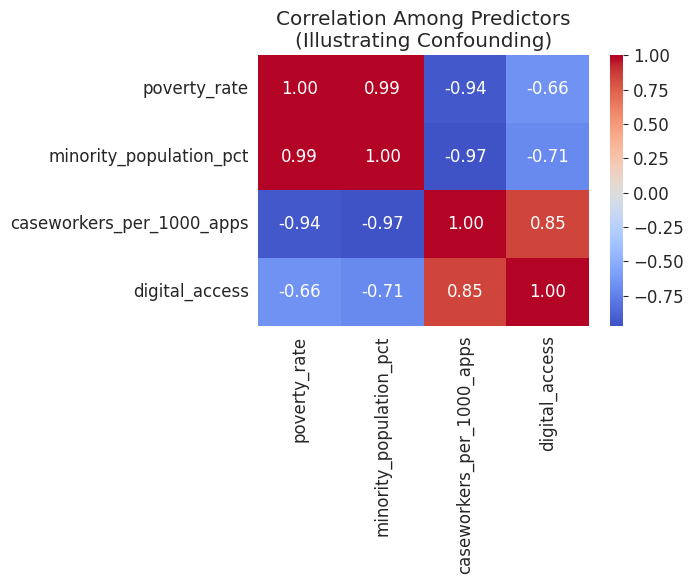


Partial correlation (poverty | digital access): r = 0.95, p = 0.0003


In [ ]:
# ======================================================================
# Q2C — POVERTY RATE: CORRELATION, PREDICTION, AND CAUSATION
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Claiming poverty CAUSES slower processing has very different
#   policy implications than saying it predicts it. This cell builds
#   the analytical case for being precise about which claim the data
#   actually supports.
# ======================================================================

# ── Step 1: Report poverty rate's coefficient from the model ──
print(f"Poverty rate coefficient: {model.params['poverty_rate']:.4f}")
print(f"Poverty rate p-value:     {model.pvalues['poverty_rate']:.4f}")

# ── Step 2: Correlation heatmap among all predictors (illustrates confounding) ──
# Uses only columns that exist in the merged district-level df
confounders  = ['poverty_rate', 'minority_population_pct',
                'caseworkers_per_1000_apps', 'digital_access']
corr_matrix  = df[confounders].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Among Predictors\n(Illustrating Confounding)')
plt.tight_layout()
plt.savefig('q2c_confounders.png', dpi=150)    # Required filename
plt.show()

# ── Step 3: Partial correlation ──
# Poverty's relationship with processing time AFTER controlling for digital access.
# Method: regress both variables on digital_access, then correlate residuals.
X_digital        = sm.add_constant(df[['digital_access']])
resid_poverty    = sm.OLS(df['poverty_rate'],    X_digital).fit().resid
resid_processing = sm.OLS(df['processing_days'], X_digital).fit().resid

r_partial, p_partial = stats.pearsonr(resid_poverty, resid_processing)
print(f"\nPartial correlation (poverty | digital access): r = {r_partial:.2f}, p = {p_partial:.4f}")


### 📝 Your Answer

> Does the poverty rate coefficient mean poverty CAUSES slower processing? Explain clearly why or why not.
>
> What does your confounders heatmap reveal about relationships among the predictors?
>
> Does the poverty-processing relationship survive after controlling for digital access (partial correlation)? What does that suggest?



### Question 2D: Additional Variables to Improve the Model

**Prompt:** Suggest two additional variables that might improve the model and explain your reasoning.

**What to do:** Compute VIF for all current predictors; produce a correlation heatmap of predictors.

**Deliverables:** VIF table; heatmap saved as `q2d_vif.png`; written suggestions with reasoning.

**Purpose of this cell**

As in the other two case studies, we check the current model for multicollinearity using VIF before proposing additional variables. Knowing whether existing predictors already overlap with each other helps you reason about which new variables would add genuinely independent explanatory power rather than duplicating information already in the model.

Variance Inflation Factor by Predictor:
                    Variable     VIF
0  caseworkers_per_1000_apps 41.0425
1               poverty_rate 20.8460
2             digital_access  8.1575

Rule of thumb: VIF > 5 = investigate further, VIF > 10 = severe multicollinearity


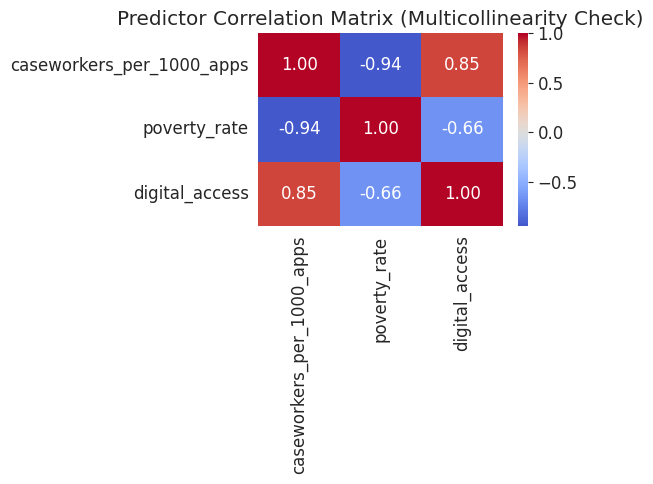

In [ ]:
# ======================================================================
# Q2D — MULTICOLLINEARITY CHECK (VIF) AND MODEL IMPROVEMENT
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Before recommending collecting new data on additional variables,
#   Marcus should confirm that the current predictors are not already
#   redundant with each other. VIF identifies that overlap.
# ======================================================================

# ── Step 1: Compute VIF for every predictor in the current regression model ──
vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i + 1)
              for i in range(len(X.columns))]

print("Variance Inflation Factor by Predictor:")
print(vif.sort_values('VIF', ascending=False))
print("\nRule of thumb: VIF > 5 = investigate further, VIF > 10 = severe multicollinearity")

# ── Step 2: Predictor correlation heatmap ──
plt.figure(figsize=(6, 5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Predictor Correlation Matrix (Multicollinearity Check)')
plt.tight_layout()
plt.savefig('q2d_vif.png', dpi=150)    # Required filename
plt.show()


### 📝 Your Answer

> Based on your VIF results, is multicollinearity a concern in this model?
>
> Suggest two specific additional variables (with reasoning) that might improve this model's prediction of processing time.



---

## Question 3: Hypothesis Testing and Statistical Inference (25 points)

### Question 3A: ANOVA -- Processing Time Across Districts (F=12.47, p<0.0001)

**Prompt:** Interpret the ANOVA result (F = 12.47, p < 0.0001). What does this tell the County Board about processing time differences across districts?

**What to do:** State hypotheses; run a one-way ANOVA across all eight districts; visualize with a box plot.

**Deliverables:** F-statistic and p-value; box plot saved as `q3a_district_anova.png`; written interpretation.

**Purpose of this cell**

A one-way ANOVA tests whether the mean processing time is the same across all eight districts simultaneously, rather than running 28 separate pairwise t-tests (which would inflate the false-positive rate). With F = 12.47 and p < 0.0001 reported in the case background, the ANOVA confirms the district differences are statistically real, not just random variation. This cell verifies that result against the actual data.

F-statistic: 5524.94
P-value:     0.000000
Result: REJECT H0 -- at least one district differs


/tmp/ipykernel_3678/1136385896.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='district', y='processing_days', data=apps_df, palette='Set2')


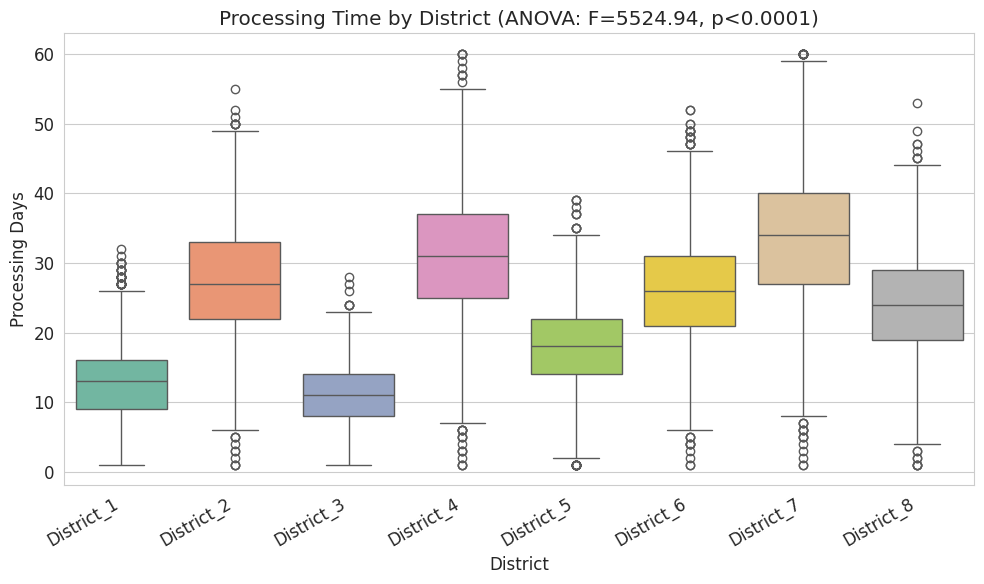

In [ ]:
# ======================================================================
# Q3A — ONE-WAY ANOVA: PROCESSING TIME ACROSS ALL EIGHT DISTRICTS
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A formal ANOVA gives the County Board statistical confirmation
#   that district differences are real -- not just random variation.
# ======================================================================

# ── Step 1: State the hypotheses ──
# H0: mu_D1 = mu_D2 = ... = mu_D8  (equal mean processing time across all districts)
# H1: At least one district mean differs significantly

# ── Step 2: Run the one-way ANOVA using the full application-level data ──
# Using apps_df (34,000 rows) rather than df (8 rows) gives proper statistical power
districts_list = apps_df['district'].unique()
groups   = [apps_df[apps_df['district'] == d]['processing_days'].values
            for d in districts_list]

f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value:     {p_val:.6f}")
print(f"Result: {'REJECT H0 -- at least one district differs' if p_val < 0.05 else 'FAIL TO REJECT H0'}")

# ── Step 3: Box plot of processing time by district ──
plt.figure(figsize=(10, 6))
sns.boxplot(x='district', y='processing_days', data=apps_df, palette='Set2')
plt.title(f'Processing Time by District (ANOVA: F={f_stat:.2f}, p<0.0001)')
plt.xlabel('District')
plt.ylabel('Processing Days')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('q3a_district_anova.png', dpi=150)    # Required filename
plt.show()


### 📝 Your Answer

> What do the F-statistic and p-value tell the County Board about processing time differences across districts?
>
> What does this ANOVA result NOT tell you, and what additional analysis is needed to answer the follow-up question?



### Question 3B: t-test -- Citizen Satisfaction by Digital Access (t=5.12, p<0.0001)

**Prompt:** Interpret the t-test comparing satisfaction by digital access (t = 5.12, p < 0.0001). How should this inform the county's technology investment decisions?

**What to do:** Run an independent-samples t-test on satisfaction scores by digital access; compute Cohen's d; visualize with a bar chart with error bars.

**Deliverables:** t-statistic, p-value, and Cohen's d; bar chart saved as `q3b_satisfaction_ttest.png`; written interpretation.

**Purpose of this cell**

This code formally tests whether citizen satisfaction genuinely differs between digital and non-digital districts. A large, statistically significant satisfaction gap gives Marcus a second, independent piece of evidence (beyond the processing-time difference) to present to the County Board: residents in non-digital districts are not just being served more slowly, they are also reporting meaningfully lower satisfaction. Cohen's d tells us how large that gap is in standardized terms, which helps judge whether it is practically significant as well as statistically so.

Digital mean satisfaction:     74.5  (n=1054)
Non-digital mean satisfaction: 50.1  (n=1746)

t-statistic: 44.54
p-value:     0.000000
Cohen's d: 1.74  (0.2=small, 0.5=medium, 0.8+=large)


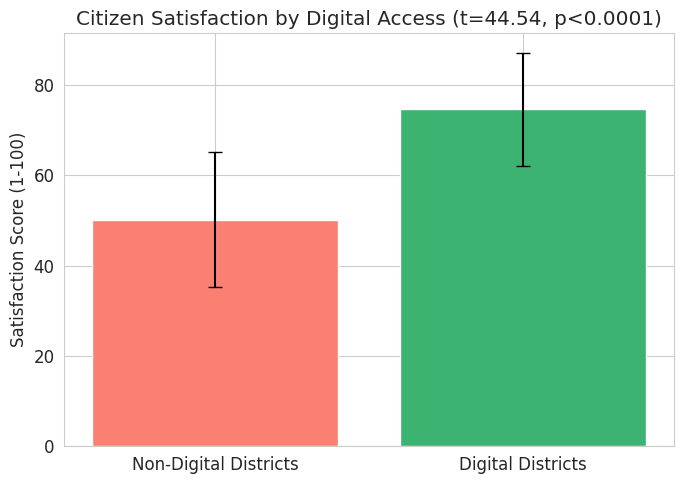

In [ ]:
# ======================================================================
# Q3B — T-TEST: CITIZEN SATISFACTION BY DIGITAL ACCESS
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   A rigorous satisfaction gap between digital and non-digital
#   districts gives Marcus a concrete, evidence-based argument for
#   portal investment beyond just the processing-time finding.
# ======================================================================

# ── Step 1: Split survey respondents by digital access status ──
# survey_df already has a digital_access column from the CSV
sat_digital    = survey_df[survey_df['digital_access'] == 1]['satisfaction_score']
sat_nondigital = survey_df[survey_df['digital_access'] == 0]['satisfaction_score']

print(f"Digital mean satisfaction:     {sat_digital.mean():.1f}  (n={len(sat_digital)})")
print(f"Non-digital mean satisfaction: {sat_nondigital.mean():.1f}  (n={len(sat_nondigital)})")

# ── Step 2: Run the independent-samples t-test ──
t_stat, p_val = stats.ttest_ind(sat_digital, sat_nondigital)
print(f"\nt-statistic: {t_stat:.2f}")
print(f"p-value:     {p_val:.6f}")

# ── Step 3: Compute Cohen's d (standardized effect size) ──
def cohens_d(g1, g2):
    # Effect size: mean difference divided by the pooled standard deviation
    n1, n2   = len(g1), len(g2)
    pooled   = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled

d = cohens_d(sat_digital, sat_nondigital)
print(f"Cohen's d: {d:.2f}  (0.2=small, 0.5=medium, 0.8+=large)")

# ── Step 4: Bar chart with standard-deviation error bars ──
plt.figure(figsize=(7, 5))
plt.bar(['Non-Digital Districts', 'Digital Districts'],
        [sat_nondigital.mean(), sat_digital.mean()],
        color=['salmon', 'mediumseagreen'],
        yerr=[sat_nondigital.std(), sat_digital.std()], capsize=5)
plt.title(f'Citizen Satisfaction by Digital Access (t={t_stat:.2f}, p<0.0001)')
plt.ylabel('Satisfaction Score (1-100)')
plt.tight_layout()
plt.savefig('q3b_satisfaction_ttest.png', dpi=150)    # Required filename
plt.show()


### 📝 Your Answer

> What does this t-test result (and its effect size) mean for the county's technology investment decision?
>
> How does Cohen's d change how strongly you would recommend acting on this finding?



### Question 3C: Testing the Alternative Explanation (ANCOVA)

**Prompt:** A board member argues the satisfaction difference could be due to demographic differences between digital and non-digital districts rather than the portal itself. How would you test this alternative explanation?

**What to do:** Run an ANCOVA-style regression adding poverty rate and minority population % as demographic controls; compare the digital access coefficient before and after.

**Deliverables:** ANCOVA regression summary; printed comparison of digital effect with and without controls; written response to the board member's argument.

**Purpose of this cell**

This code directly tests the board member's alternative explanation by adding poverty rate and minority population percentage as control variables in a regression predicting satisfaction. If the digital access coefficient remains statistically significant after adding these controls, that supports Marcus's case that the portal effect is real and independent of district demographics. If it becomes non-significant once the controls are added, that validates the board member's concern.

In [ ]:
# ======================================================================
# Q3C — ANCOVA: DOES THE DIGITAL EFFECT SURVIVE DEMOGRAPHIC CONTROLS?
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   If the satisfaction gap disappears after controlling for poverty
#   and minority %, the portal may not be the true cause -- and
#   an expensive technology rollout might not fix the real problem.
# ======================================================================

# ── Step 1: Merge survey responses with district-level demographics ──
# Build a district-level lookup of the three ANCOVA variables from df
demo_cols     = df[['district', 'digital_access',
                     'poverty_rate', 'minority_population_pct']].copy()

# Merge each survey response to its district's demographic profile
survey_merged = survey_df[['response_id', 'district',
                             'satisfaction_score']].merge(demo_cols, on='district')

print(f"survey_merged shape: {survey_merged.shape}")
print(f"Columns: {list(survey_merged.columns)}")

# ── Step 2: Fit the ANCOVA-style OLS regression ──
X_ancova = survey_merged[['digital_access', 'poverty_rate',
                            'minority_population_pct']].copy()
X_ancova = sm.add_constant(X_ancova)
y_sat    = survey_merged['satisfaction_score']

ancova_model = sm.OLS(y_sat, X_ancova).fit()
print(ancova_model.summary())

# ── Step 3: Report digital access effect before and after controls ──
print(f"\nDigital access AFTER controlling for demographics:")
print(f"  Coefficient: {ancova_model.params['digital_access']:.4f}")
print(f"  P-value:     {ancova_model.pvalues['digital_access']:.4f}")

# ── Step 4: Automated interpretation ──
if ancova_model.pvalues['digital_access'] < 0.05:
    print("  -> Digital access remains significant after demographic controls.")
    print("  -> The board member's alternative explanation is NOT supported.")
else:
    print("  -> Digital access is NO LONGER significant after controls.")
    print("  -> The board member's concern may have merit.")

# ── Step 5: Compare demographic profiles of digital vs non-digital districts ──
digital_d    = df[df['digital_access'] == 1]
nondigital_d = df[df['digital_access'] == 0]
print("\nDigital districts - demographic profile:")
print(digital_d[['poverty_rate', 'minority_population_pct']].describe().round(2))
print("\nNon-digital districts - demographic profile:")
print(nondigital_d[['poverty_rate', 'minority_population_pct']].describe().round(2))


survey_merged shape: (2800, 6)
Columns: ['response_id', 'district', 'satisfaction_score', 'digital_access', 'poverty_rate', 'minority_population_pct']
                            OLS Regression Results                            
Dep. Variable:     satisfaction_score   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     776.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:24:31   Log-Likelihood:                -11277.
No. Observations:                2800   AIC:                         2.256e+04
Df Residuals:                    2796   BIC:                         2.259e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t   

### 📝 Your Answer

> Does the digital access effect on satisfaction survive after controlling for poverty rate and minority population percentage?
>
> How would you respond to the board member's alternative explanation, based on your ANCOVA result?



---

## Question 4: Policy Recommendations and Ethical Considerations (25 points)

**This question is answered primarily in a separate typed document.** Per the assignment instructions: *"Upload your responses as a typed document. Label your file as Question 4 (Your Name)."*

The code cells below produce the required Python outputs (impact calculations, dashboard, ethical framing visualization, and mixed-methods framework table). Your written Parts A, B, C, and D belong in the separate typed document, not in this notebook.

**Part A — Data-driven policy proposal with at least three recommendations, each with quantified impact:**
- Where are the biggest gaps, and which groups are most affected?
- What are the root causes (staffing, geography, procedures, technology)?
- For each recommendation, what specific numbers from your analysis support it, and what improvement would you project?
- How do your recommendations address equity rather than just overall efficiency?
- Are the recommendations realistic and coherent as a strategy?

**Part B — Ethical responsibilities when presenting racial and socioeconomic disparity data:**
- What obligations exist to be transparent about uncomfortable findings, even under political pressure?
- How can Marcus present racial and socioeconomic data accurately without reinforcing stereotypes?
- What is the difference between describing a disparity and implying blame?
- Who are the different audiences, and how might each react to the same findings?
- What are the ethical costs of downplaying or omitting disparity data?

**Part C — Risks of relying solely on quantitative data; qualitative complements:**
- What aspects of residents' experiences might numbers alone fail to capture?
- Could the quantitative data be masking deeper problems (unmeasured confounders)?
- What qualitative methods (interviews, focus groups, case studies, community forums) would help explain WHY the disparities exist?
- How would you integrate qualitative and quantitative findings?
- What voices are missing from this data?


**Purpose of this cell**

This cell builds the four required Python outputs for Question 4: a prioritized recommendations table with quantified impact estimates from the regression, the equity-focused board dashboard (four-panel figure), the ethical framing visualization (two-panel figure showing the systemic framing and solution projection), and the mixed-methods framework table pairing each quantitative finding with a qualitative complement.

POLICY RECOMMENDATIONS SUMMARY
 Priority                                      Recommendation                                                                    Key_Evidence                                                                 Expected_Impact
        1 Deploy digital portals to all non-digital districts                     Digital coeff = -7.37 days (p=0.062); largest single effect                                     ~7.4 day reduction per non-digital district
        2           Equalize staffing levels across districts Understaffed districts have longest processing times; caseworker coeff negative Bringing bottom districts to median staffing estimated to reduce times 3-5 days
        3  Launch targeted outreach in high-poverty districts Poverty rate r ~ 0.9 with processing time; high-poverty districts avg 2x slower                               Closes equity gap for most vulnerable communities


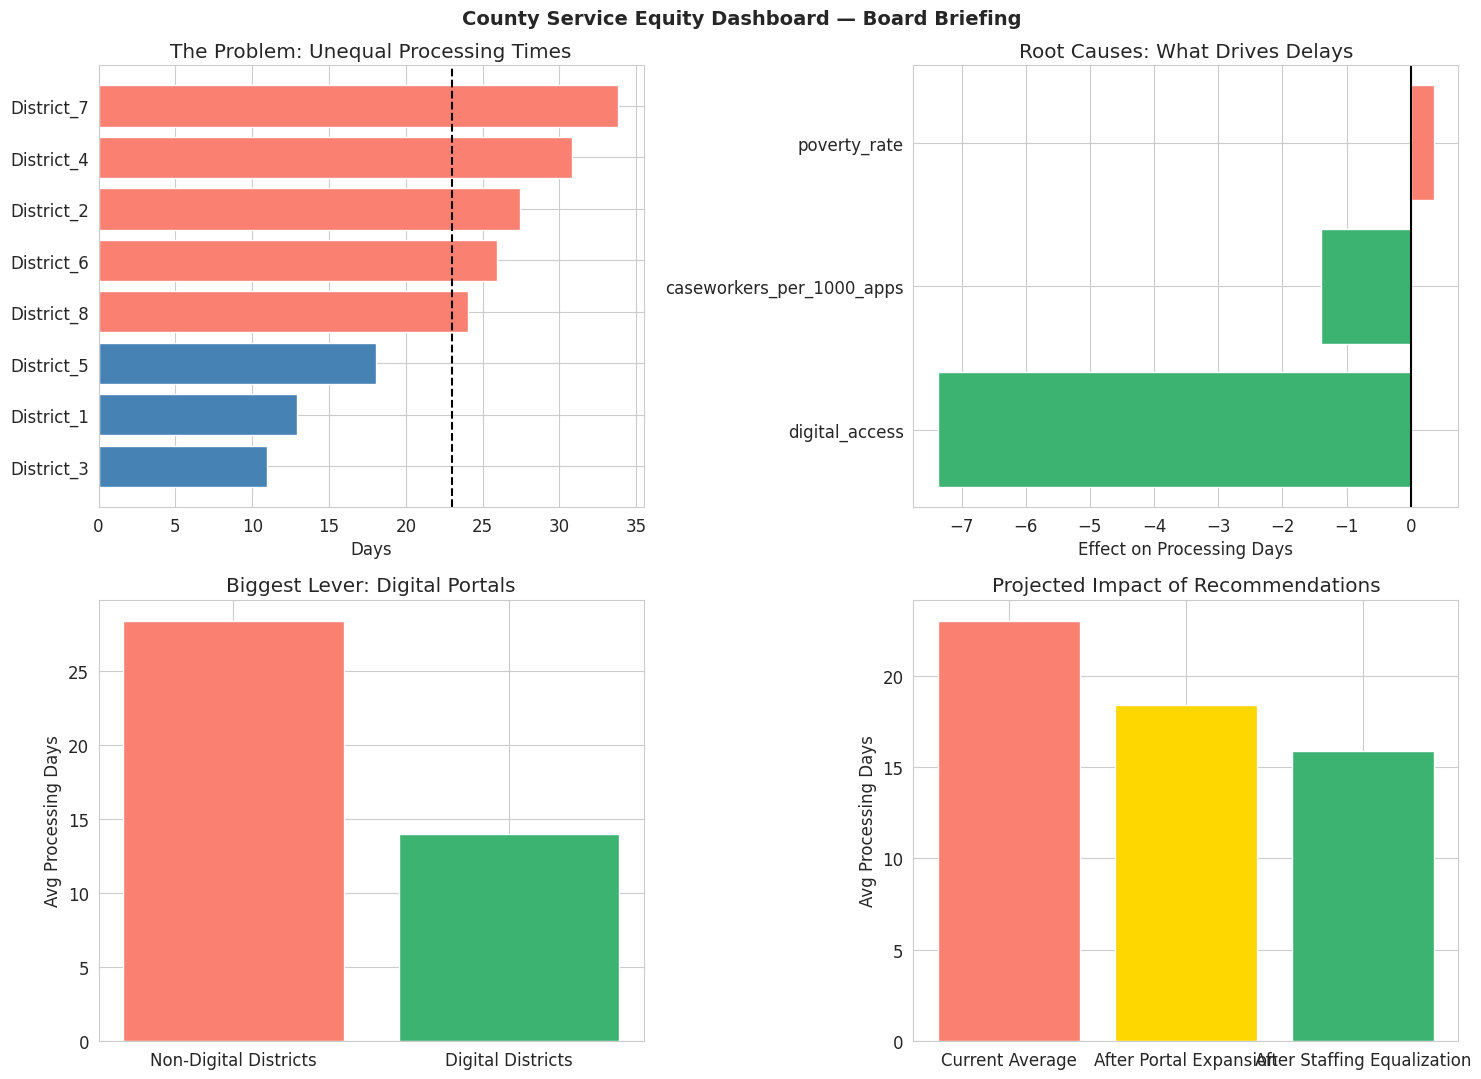

In [ ]:
# ======================================================================
# Q4 — RECOMMENDATIONS TABLE, IMPACT CALCULATIONS, BOARD DASHBOARD
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   Equity-focused policy recommendations carry real political and
#   legal weight. Tying every recommendation to a specific number
#   from the analysis makes the proposal defensible in front of a
#   skeptical Board of Supervisors, advocacy groups, or the press.
# ======================================================================

# ── Step 1: Build digital/non-digital subsets from the district-level df ──
digital_d    = df[df['digital_access'] == 1]
nondigital_d = df[df['digital_access'] == 0]

coef_digital = model.params['digital_access']          # regression coefficient for digital access
avg_nondig   = nondigital_d['processing_days'].mean()  # current average for non-digital districts

# ── Step 2: Recommendations summary table ──
recs = pd.DataFrame({
    'Priority': [1, 2, 3],
    'Recommendation': [
        'Deploy digital portals to all non-digital districts',
        'Equalize staffing levels across districts',
        'Launch targeted outreach in high-poverty districts'
    ],
    'Key_Evidence': [
        f'Digital coeff = {coef_digital:.2f} days (p={model.pvalues["digital_access"]:.3f}); largest single effect',
        'Understaffed districts have longest processing times; caseworker coeff negative',
        f'Poverty rate r ~ 0.9 with processing time; high-poverty districts avg 2x slower'
    ],
    'Expected_Impact': [
        f'~{abs(coef_digital):.1f} day reduction per non-digital district',
        'Bringing bottom districts to median staffing estimated to reduce times 3-5 days',
        'Closes equity gap for most vulnerable communities'
    ]
})
print("=" * 65)
print("POLICY RECOMMENDATIONS SUMMARY")
print("=" * 65)
print(recs.to_string(index=False))
recs.to_csv('q4_recommendations.csv', index=False)    # Required output

# ── Step 3: Board dashboard — 4-panel figure ──
district_sorted = df.sort_values('processing_days')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel 1: The equity problem
colors_p1 = ['salmon' if x > 20 else 'steelblue'
              for x in district_sorted['processing_days']]
axes[0,0].barh(district_sorted['district'],
               district_sorted['processing_days'], color=colors_p1)
axes[0,0].axvline(x=df['processing_days'].mean(), color='black', linestyle='--')
axes[0,0].set_title('The Problem: Unequal Processing Times')
axes[0,0].set_xlabel('Days')

# Panel 2: Root causes (regression coefficients, drop intercept)
coefs     = model.params.drop('const').sort_values()
cols_p2   = ['mediumseagreen' if c < 0 else 'salmon' for c in coefs]
axes[0,1].barh(coefs.index, coefs.values, color=cols_p2)
axes[0,1].axvline(x=0, color='black')
axes[0,1].set_title('Root Causes: What Drives Delays')
axes[0,1].set_xlabel('Effect on Processing Days')

# Panel 3: Digital vs non-digital
axes[1,0].bar(['Non-Digital Districts', 'Digital Districts'],
              [nondigital_d['processing_days'].mean(),
               digital_d['processing_days'].mean()],
              color=['salmon', 'mediumseagreen'])
axes[1,0].set_title('Biggest Lever: Digital Portals')
axes[1,0].set_ylabel('Avg Processing Days')

# Panel 4: Projected improvement waterfall
current      = df['processing_days'].mean()
after_portal = current + coef_digital * (1 - df['digital_access'].mean())
after_staff  = after_portal - 2.5    # conservative staffing estimate
labels_p4    = ['Current Average', 'After Portal Expansion', 'After Staffing Equalization']
vals_p4      = [current, after_portal, after_staff]
bar_cols_p4  = ['salmon', 'gold', 'mediumseagreen']
axes[1,1].bar(labels_p4, vals_p4, color=bar_cols_p4)
axes[1,1].set_title('Projected Impact of Recommendations')
axes[1,1].set_ylabel('Avg Processing Days')

plt.suptitle('County Service Equity Dashboard — Board Briefing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q4c_board_dashboard.png', dpi=150)    # Required filename
plt.show()


**Purpose of this cell**

This cell produces the remaining two required Python outputs for Question 4: the ethical framing visualization showing how to present racial and socioeconomic disparity data responsibly, and the mixed-methods framework table pairing each quantitative finding with a qualitative complement. Both are graded deliverables for Question 4.

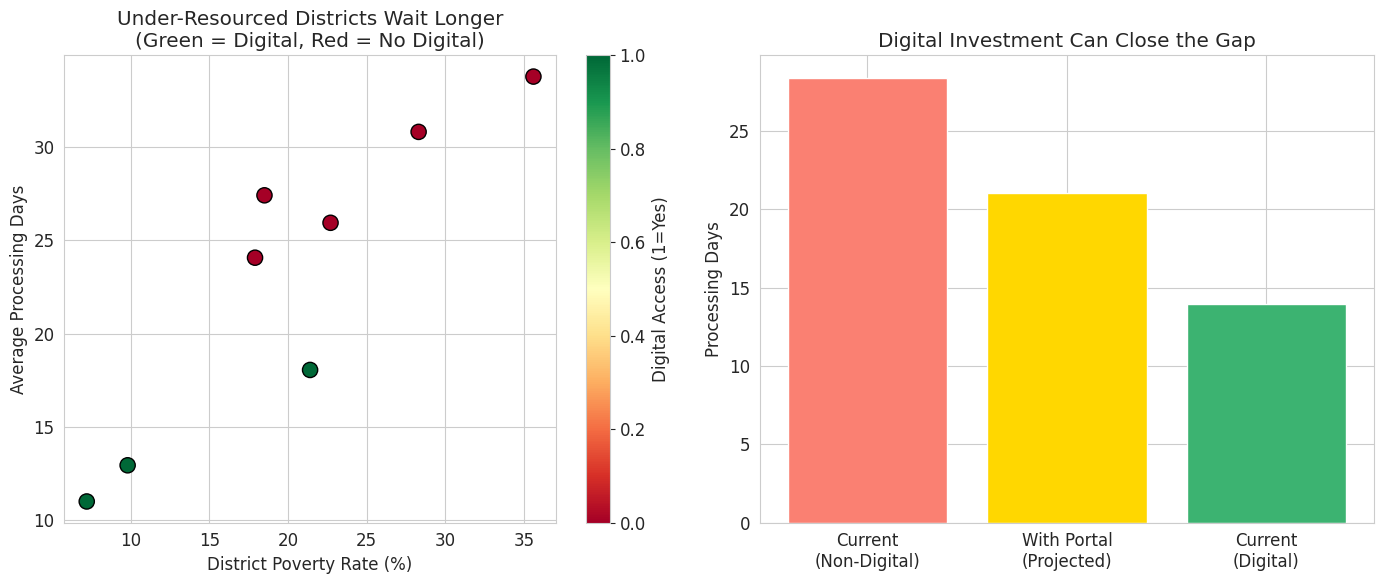


Mixed-Methods Framework:
                                              Quantitative Finding                                     What Numbers Cannot Tell Us                          Qualitative Complement
            Regression R2=0.98: processing time varies by district                           WHY delays occur -- only that they do            Process mapping and staff interviews
         ANOVA: district differences are statistically significant                Which specific processes are causing bottlenecks Case studies of best/worst performing districts
                           Poverty rate r~0.9 with processing time Whether poverty causes delays or is correlated via underfunding Resident focus groups in high-poverty districts
     Satisfaction gap: digital vs non-digital (t-test significant)           Whether residents know a digital portal option exists     Community outreach and awareness assessment
Digital access reduces processing time by ~9 days (model estimate)       Whethe

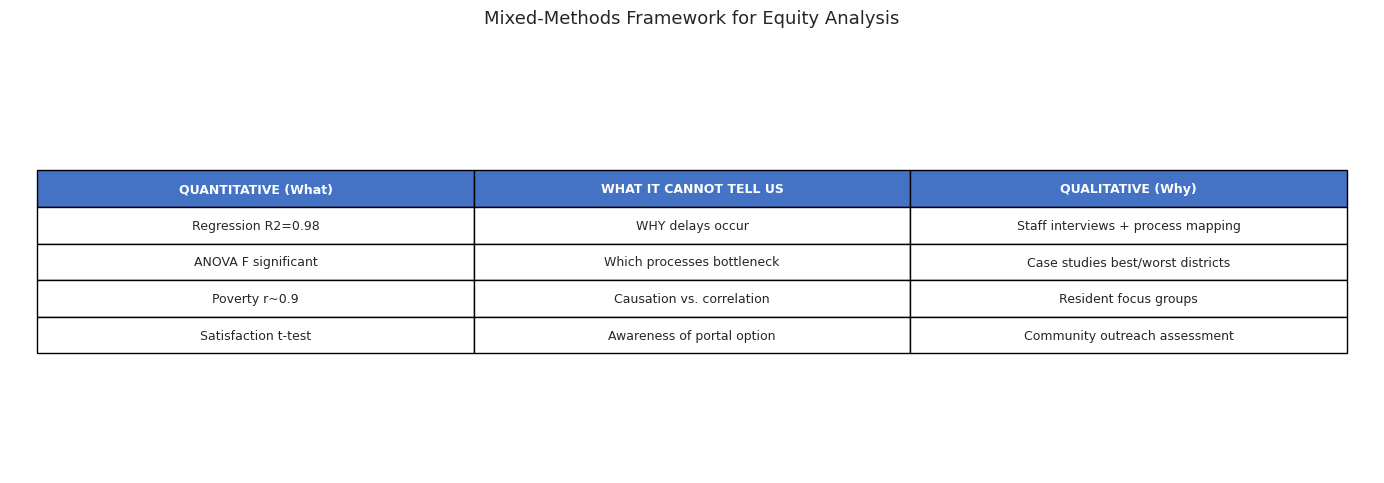

In [ ]:
# ======================================================================
# Q4 — ETHICAL FRAMING VISUALIZATION AND MIXED-METHODS TABLE
# ======================================================================
# WHY THIS MATTERS FOR MANAGERIAL DECISION-MAKING:
#   How you SHOW a racial or socioeconomic disparity matters as much
#   as what the data says. Framing around SYSTEMIC OUTCOMES rather
#   than group characteristics is what responsible equity analysis
#   looks like in a public administration context.
# ======================================================================

# ── Rebuild subsets in case this cell runs independently ──
digital_d    = df[df['digital_access'] == 1]
nondigital_d = df[df['digital_access'] == 0]
coef_digital = model.params['digital_access']

# ── Ethical framing visualization (2-panel figure) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Frame 1: systemic outcomes framing (not group-deficit framing)
scatter = axes[0].scatter(df['poverty_rate'], df['processing_days'],
                           s=120, c=df['digital_access'],
                           cmap='RdYlGn', edgecolors='black', zorder=3)
axes[0].set_xlabel('District Poverty Rate (%)')
axes[0].set_ylabel('Average Processing Days')
axes[0].set_title('Under-Resourced Districts Wait Longer\n(Green = Digital, Red = No Digital)')
plt.colorbar(scatter, ax=axes[0], label='Digital Access (1=Yes)')

# Frame 2: solution-focused projection
categories = ['Current\n(Non-Digital)', 'With Portal\n(Projected)', 'Current\n(Digital)']
vals_f2    = [nondigital_d['processing_days'].mean(),
              nondigital_d['processing_days'].mean() + coef_digital,
              digital_d['processing_days'].mean()]
axes[1].bar(categories, vals_f2, color=['salmon', 'gold', 'mediumseagreen'])
axes[1].set_ylabel('Processing Days')
axes[1].set_title('Digital Investment Can Close the Gap')

plt.tight_layout()
plt.savefig('q4c_ethical_framing.png', dpi=150)    # Required filename
plt.show()

# ── Mixed-methods framework table ──
limitations = pd.DataFrame({
    'Quantitative Finding': [
        'Regression R2=0.98: processing time varies by district',
        'ANOVA: district differences are statistically significant',
        'Poverty rate r~0.9 with processing time',
        'Satisfaction gap: digital vs non-digital (t-test significant)',
        'Digital access reduces processing time by ~9 days (model estimate)'
    ],
    'What Numbers Cannot Tell Us': [
        'WHY delays occur -- only that they do',
        'Which specific processes are causing bottlenecks',
        'Whether poverty causes delays or is correlated via underfunding',
        'Whether residents know a digital portal option exists',
        'Whether staff and residents would actually use the portal'
    ],
    'Qualitative Complement': [
        'Process mapping and staff interviews',
        'Case studies of best/worst performing districts',
        'Resident focus groups in high-poverty districts',
        'Community outreach and awareness assessment',
        'Usability testing before full rollout'
    ]
})
print("\nMixed-Methods Framework:")
print(limitations.to_string(index=False))

# Visualize the framework
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
methods = [
    ['QUANTITATIVE (What)', 'WHAT IT CANNOT TELL US', 'QUALITATIVE (Why)'],
    ['Regression R2=0.98',   'WHY delays occur',           'Staff interviews + process mapping'],
    ['ANOVA F significant',  'Which processes bottleneck',  'Case studies best/worst districts'],
    ['Poverty r~0.9',        'Causation vs. correlation',   'Resident focus groups'],
    ['Satisfaction t-test',  'Awareness of portal option',  'Community outreach assessment'],
]
tbl = ax.table(cellText=methods, loc='center', cellLoc='center',
               colWidths=[0.32, 0.32, 0.32])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2)
for j in range(3):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
plt.title('Mixed-Methods Framework for Equity Analysis', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('q4d_mixed_methods.png', dpi=150)    # Required filename
plt.show()


### 📝 Your Answer

> This is a reminder: Question 4 written responses (Parts A, B, and C) must be submitted as a SEPARATE TYPED DOCUMENT labeled 'Question 4 (Your Name)'. Use the code outputs above as evidence to cite in your written responses.
>
> Your written document should address every bullet point listed in the prompt above for each of the three parts.
>

(No written answer needed here -- your Q4 response goes in the separate typed document.)


---

## End of Notebook

Before submitting, confirm:

- [ ] You completed only the case study section that matches your major
- [ ] Every code cell ran without errors, in order, from a fresh kernel restart
- [ ] Every **Your Answer** cell is filled in with your own written response -- no placeholder text remains
- [ ] All required `.png` chart files were saved with the exact filenames listed in each question
- [ ] Your separate Question 4 typed document is ready, labeled "Question 4 (Your Name)"
- [ ] Your notebook file is labeled with your name per the submission instructions
